# Predicción de resultados del Mundial 2026: un pipeline completo de ML

**Qué es esto**: un sistema que predice resultados de fútbol modelando los goles de cada
equipo como dos procesos de Poisson (local y visitante) en vez de clasificar directamente
"quién gana" -- de ahí se derivan matemáticamente el marcador más probable, la probabilidad
de victoria/empate/derrota, y quién avanza en un cruce de eliminatoria. Aplicado al Mundial
2026 (48 selecciones, formato nuevo), con reentrenamiento continuo a medida que se juegan
rondas reales.

**Este notebook es el recorrido completo**, pensado para leerse de principio a fin: de dónde
salen los datos, cómo se limpian, qué variables se construyen y por qué, qué supuestos
estadísticos se comprueban antes de modelar, cómo se elige la familia de modelo con evidencia
(no con una corazonada), y qué predice el sistema hoy.

**Para ejecutarlo fuera de este repositorio (p.ej. en Kaggle)**: solo hace falta cambiar
`DIR_DATOS` en la siguiente celda para que apunte a donde subas `data/processed/`,
`results/` y `models/checkpoints/pre_mundial/` como dataset adjunto -- el resto del notebook
no depende de ninguna otra ruta.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.stats import poisson

# Única ruta que hace falta tocar para ejecutar esto fuera del repo (p.ej. Kaggle):
# apunta a una carpeta que contenga data/, results/ y models/ tal cual están aquí.
DIR_DATOS = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DIR_RAW = DIR_DATOS / "data" / "raw"
DIR_PROCESSED = DIR_DATOS / "data" / "processed"
DIR_RESULTS = DIR_DATOS / "results"
DIR_MODELOS = DIR_DATOS / "models"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

# --- Paleta de series validada para daltonismo (los 8 tonos y su ORDEN están
# elegidos para maximizar la separación mínima entre colores adyacentes bajo
# deuteranopia/protanopia -- el orden no es estético, es parte de la garantía) ---
AZUL = "#2a78d6"       # serie 1 -- énfasis principal
AQUA = "#1baf7a"       # serie 2
AMARILLO = "#eda100"   # serie 3
VERDE = "#008300"      # serie 4 / "bien"
VIOLETA = "#4a3aa7"    # serie 5
ROJO = "#e34948"       # serie 6 / "mal"
MAGENTA = "#e87ba4"    # serie 7
NARANJA = "#eb6834"    # serie 8
GRIS = "#898781"        # neutro / no-destacado
GRIS_CLARO = "#e1e0d9"  # gridlines
TINTA = "#0b0b0b"
PALETA_CATEGORICA = [AZUL, AQUA, AMARILLO, VERDE, VIOLETA, ROJO, MAGENTA, NARANJA]

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRIS, "axes.labelcolor": TINTA,
    "text.color": TINTA, "xtick.color": TINTA, "ytick.color": TINTA,
    "font.size": 11, "axes.grid": False,
    "font.family": "sans-serif",
})


def limpiar_ejes(ax):
    ax.spines["left"].set_color(GRIS_CLARO)
    ax.spines["bottom"].set_color(GRIS_CLARO)
    ax.tick_params(colors=GRIS)
    return ax


print(f"Datos desde: {DIR_DATOS}")

Datos desde: /Users/danielcanteragomez/portfolio/wc-2026-match-predictor


## 1. Los datos: qué hay y de dónde sale

Dos fuentes públicas, sin necesitar cuenta ni API key:
- **Histórico de partidos internacionales** (1872 → hoy): espejo en GitHub del dataset de
  Kaggle *"International football results"*.
- **Elo por selección**: `eloratings.net`, Elo posterior a cada partido de las 48
  clasificadas al Mundial 2026.

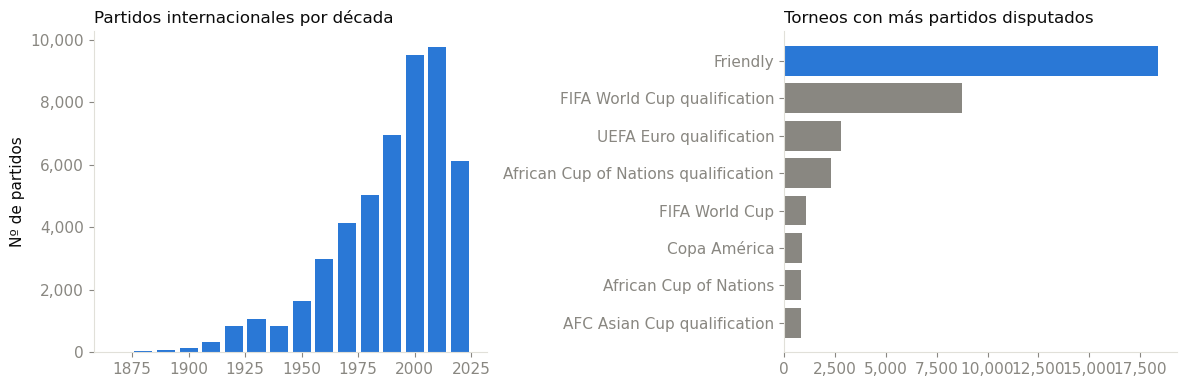

Total de partidos: 49,501  |  Rango: 1872-2026  |  Selecciones distintas: 336  |  Torneos distintos: 200


In [2]:
df_raw = pd.read_csv(DIR_RAW / "results.csv", parse_dates=["date"])

n_total = len(df_raw)
rango = (df_raw["date"].min().year, df_raw["date"].max().year)
n_selecciones = pd.concat([df_raw["home_team"], df_raw["away_team"]]).nunique()
n_torneos = df_raw["tournament"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Partidos por década ---
por_decada = (df_raw["date"].dt.year // 10 * 10).value_counts().sort_index()
ax = axes[0]
ax.bar(por_decada.index, por_decada.values, width=8, color=AZUL)
ax.set_title("Partidos internacionales por década", loc="left", fontsize=12, color=TINTA)
ax.set_ylabel("Nº de partidos")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
limpiar_ejes(ax)

# --- Top torneos ---
ax = axes[1]
top_torneos = df_raw["tournament"].value_counts().head(8).sort_values()
colores_top = [GRIS] * (len(top_torneos) - 1) + [AZUL]
ax.barh(top_torneos.index, top_torneos.values, color=colores_top)
ax.set_title("Torneos con más partidos disputados", loc="left", fontsize=12, color=TINTA)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
limpiar_ejes(ax)

plt.tight_layout()
plt.show()

print(f"Total de partidos: {n_total:,}  |  Rango: {rango[0]}-{rango[1]}  |  "
      f"Selecciones distintas: {n_selecciones}  |  Torneos distintos: {n_torneos}")

## 2. Calidad de datos y limpieza

Antes de construir ninguna feature: ¿hay nulos, duplicados o valores imposibles? Los únicos
nulos esperables son los marcadores de partidos **programados pero no jugados todavía**
(p.ej. cruces de eliminatoria del propio Mundial 2026 que dependen de un resultado anterior)
-- cualquier otro nulo sería un problema de la fuente.

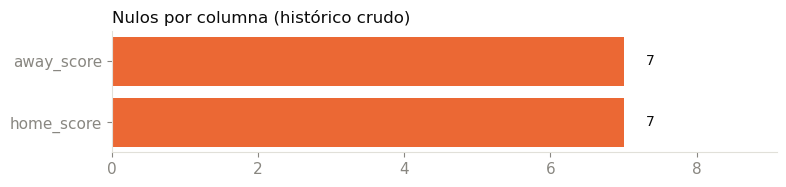

Partidos sin marcador: 7 -- todos son partidos del Mundial 2026 programados pero aún no jugados (verificado: torneo == 'FIFA World Cup' y año 2026).


In [3]:
nulos = df_raw.isna().sum()
nulos = nulos[nulos > 0]

fig, ax = plt.subplots(figsize=(8, max(2, 0.4 * len(nulos))))
if len(nulos):
    ax.barh(nulos.index, nulos.values, color=NARANJA)
    for i, v in enumerate(nulos.values):
        ax.text(v + 0.3, i, f"{v}", va="center", color=TINTA, fontsize=10)
ax.set_title("Nulos por columna (histórico crudo)", loc="left", fontsize=12, color=TINTA)
ax.set_xlim(0, max(nulos.values, default=1) * 1.3)
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

partidos_sin_marcador = df_raw["home_score"].isna().sum()
print(f"Partidos sin marcador: {partidos_sin_marcador} -- todos son partidos del Mundial 2026 "
      f"programados pero aún no jugados (verificado: torneo == 'FIFA World Cup' y año 2026).")
assert (df_raw.loc[df_raw["home_score"].isna(), "tournament"] == "FIFA World Cup").all()
assert (df_raw.loc[df_raw["home_score"].isna(), "date"].dt.year == 2026).all()

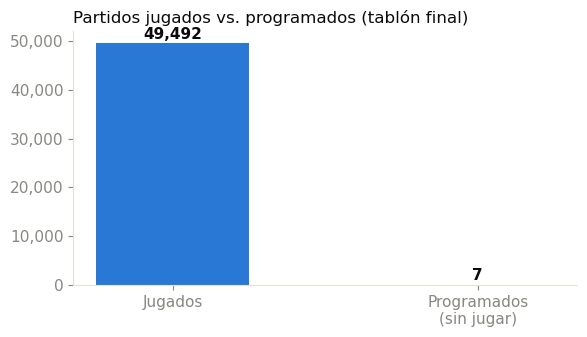

Tablón final: 49,499 filas x 81 columnas (72 nuevas respecto al histórico crudo).


In [4]:
df_features = pd.read_csv(DIR_PROCESSED / "partidos_features.csv", parse_dates=["fecha"])
df_jugados = df_features[df_features["jugado"]]

fig, ax = plt.subplots(figsize=(6, 3.5))
conteo = pd.Series({"Jugados": df_jugados.shape[0], "Programados\n(sin jugar)": (~df_features["jugado"]).sum()})
ax.bar(conteo.index, conteo.values, color=[AZUL, GRIS], width=0.5)
for i, v in enumerate(conteo.values):
    ax.text(i, v + max(conteo.values) * 0.02, f"{v:,}", ha="center", color=TINTA, fontsize=11, fontweight="bold")
ax.set_title("Partidos jugados vs. programados (tablón final)", loc="left", fontsize=12, color=TINTA)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

print(f"Tablón final: {df_features.shape[0]:,} filas x {df_features.shape[1]} columnas "
      f"({df_features.shape[1] - df_raw.shape[1]} nuevas respecto al histórico crudo).")

## 3. Feature engineering: qué variables nuevas se construyeron

Ninguna usa información posterior a la fecha del partido que describe (todas con `shift(1)`
antes de cualquier ventana móvil) -- la fuga temporal es el error más habitual y más caro en
este tipo de proyectos.

| Variable | Qué mide |
|---|---|
| `elo_diff` | Diferencia de Elo entre ambos equipos, justo antes del partido |
| `tendencia_elo` | Si el Elo de un equipo sube o baja en los últimos ~6 meses |
| `dif_forma_gf_5/10` | Diferencia de goles a favor promedio, últimos 5/10 partidos |
| `dif_racha_5/10` | Diferencia de puntos (victoria=3) en los últimos 5/10 partidos |
| `dias_descanso` | Días desde el partido anterior de cada selección |
| `es_neutral` | Si el partido se juega en campo neutral |
| `h2h_puntos_prom` / `h2h_dif_goles_prom` | Balance histórico de los enfrentamientos directos entre ESAS dos selecciones |

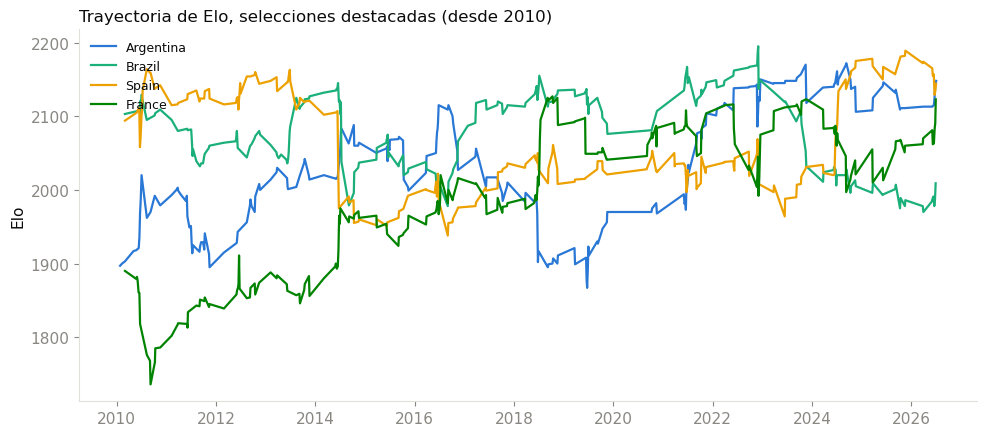

In [5]:
EQUIPOS_EJEMPLO = ["Argentina", "Brazil", "Spain", "France"]

fig, ax = plt.subplots(figsize=(10, 4.5))
for equipo, color in zip(EQUIPOS_EJEMPLO, PALETA_CATEGORICA):
    es_local = df_jugados["equipo_local"] == equipo
    es_visitante = df_jugados["equipo_visitante"] == equipo
    serie = pd.concat([
        df_jugados.loc[es_local, ["fecha", "elo_actual_local"]].rename(columns={"elo_actual_local": "elo"}),
        df_jugados.loc[es_visitante, ["fecha", "elo_actual_visitante"]].rename(columns={"elo_actual_visitante": "elo"}),
    ]).sort_values("fecha")
    serie = serie[serie["fecha"] >= "2010-01-01"]
    ax.plot(serie["fecha"], serie["elo"], color=color, linewidth=1.6, label=equipo)

ax.set_title("Trayectoria de Elo, selecciones destacadas (desde 2010)", loc="left", fontsize=12, color=TINTA)
ax.set_ylabel("Elo")
ax.legend(frameon=False, loc="upper left", fontsize=9)
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

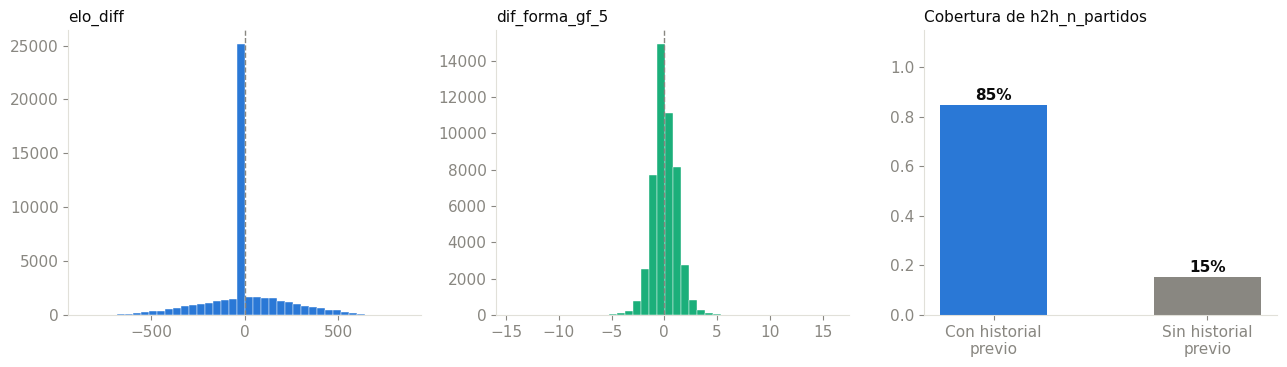

es_neutral: 26.5% de los partidos jugados en campo neutral.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

ax = axes[0]
ax.hist(df_jugados["elo_diff"], bins=40, color=AZUL, edgecolor="white", linewidth=0.3)
ax.axvline(0, color=GRIS, linewidth=1, linestyle="--")
ax.set_title("elo_diff", loc="left", fontsize=11, color=TINTA)
limpiar_ejes(ax)

ax = axes[1]
ax.hist(df_jugados["dif_forma_gf_5"].dropna(), bins=40, color=AQUA, edgecolor="white", linewidth=0.3)
ax.axvline(0, color=GRIS, linewidth=1, linestyle="--")
ax.set_title("dif_forma_gf_5", loc="left", fontsize=11, color=TINTA)
limpiar_ejes(ax)

ax = axes[2]
cobertura_h2h = (df_jugados["h2h_n_partidos"] > 0).mean()
sin_h2h = 1 - cobertura_h2h
ax.bar(["Con historial\nprevio", "Sin historial\nprevio"], [cobertura_h2h, sin_h2h], color=[AZUL, GRIS], width=0.5)
for i, v in enumerate([cobertura_h2h, sin_h2h]):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center", color=TINTA, fontsize=11, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.set_title("Cobertura de h2h_n_partidos", loc="left", fontsize=11, color=TINTA)
limpiar_ejes(ax)

plt.tight_layout()
plt.show()

print(f"es_neutral: {df_jugados['es_neutral'].mean():.1%} de los partidos jugados en campo neutral.")

## 4. Estandarización: por qué hace falta

El GLM de Poisson necesita las features en una escala comparable -- `elo_diff` se mueve en
cientos de puntos mientras que `dif_racha_5` lo hace en unidades. Sin normalizar, el solver
queda mal condicionado (coeficientes no comparables, advertencias de overflow en el
gradiente). `StandardScaler` resta la media y divide por la desviación típica de cada
columna, así que todas quedan centradas en 0 con varianza 1.

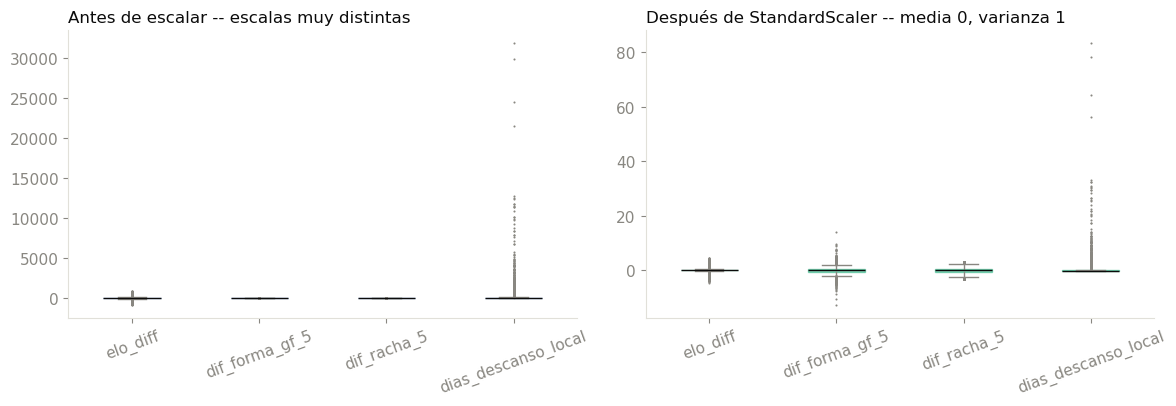

In [7]:
from sklearn.preprocessing import StandardScaler

FEATURES_EJEMPLO = ["elo_diff", "dif_forma_gf_5", "dif_racha_5", "dias_descanso_local"]
X_ejemplo = df_jugados[FEATURES_EJEMPLO].dropna()
X_escalado = pd.DataFrame(StandardScaler().fit_transform(X_ejemplo), columns=FEATURES_EJEMPLO)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ax.boxplot([X_ejemplo[c] for c in FEATURES_EJEMPLO], tick_labels=FEATURES_EJEMPLO,
           patch_artist=True, boxprops=dict(facecolor=AZUL, alpha=0.5, edgecolor=AZUL),
           medianprops=dict(color=TINTA), whiskerprops=dict(color=GRIS), capprops=dict(color=GRIS),
           flierprops=dict(marker=".", markersize=3, markerfacecolor=GRIS, markeredgecolor="none"))
ax.set_title("Antes de escalar -- escalas muy distintas", loc="left", fontsize=12, color=TINTA)
ax.tick_params(axis="x", rotation=20)
limpiar_ejes(ax)

ax = axes[1]
ax.boxplot([X_escalado[c] for c in FEATURES_EJEMPLO], tick_labels=FEATURES_EJEMPLO,
           patch_artist=True, boxprops=dict(facecolor=AQUA, alpha=0.5, edgecolor=AQUA),
           medianprops=dict(color=TINTA), whiskerprops=dict(color=GRIS), capprops=dict(color=GRIS),
           flierprops=dict(marker=".", markersize=3, markerfacecolor=GRIS, markeredgecolor="none"))
ax.set_title("Después de StandardScaler -- media 0, varianza 1", loc="left", fontsize=12, color=TINTA)
ax.tick_params(axis="x", rotation=20)
limpiar_ejes(ax)

plt.tight_layout()
plt.show()

## 5. Validar los supuestos antes de modelar

Dos preguntas que hay que responder con datos, no dar por hecho, antes de elegir Poisson
como familia de distribución y antes de decidir cuánto histórico usar:

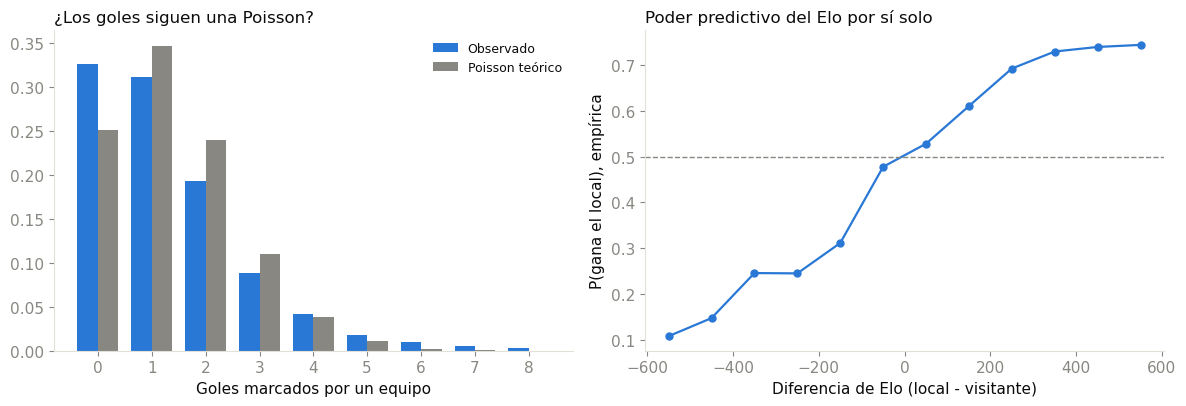

Media de goles por equipo y partido (desde 1990): 1.380  |  Varianza: 2.460 (sobredispersión: 1.78x sobre lo que pediría una Poisson pura)


In [8]:
df_moderno = df_jugados[df_jugados["fecha"] >= "1990-01-01"]
goles = pd.concat([df_moderno["goles_local"], df_moderno["goles_visitante"]])

max_goles_grafico = 8
observado = goles.value_counts(normalize=True).reindex(range(max_goles_grafico + 1), fill_value=0)
teorico = poisson.pmf(range(max_goles_grafico + 1), goles.mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
x = np.arange(max_goles_grafico + 1)
ancho = 0.38
ax.bar(x - ancho / 2, observado.values, width=ancho, color=AZUL, label="Observado")
ax.bar(x + ancho / 2, teorico, width=ancho, color=GRIS, label="Poisson teórico")
ax.set_xticks(x)
ax.set_xlabel("Goles marcados por un equipo")
ax.set_title("¿Los goles siguen una Poisson?", loc="left", fontsize=12, color=TINTA)
ax.legend(frameon=False, fontsize=9)
limpiar_ejes(ax)

# --- Poder predictivo del Elo: probabilidad empírica de victoria por bins de elo_diff ---
ax = axes[1]
bins_elo = pd.cut(df_moderno["elo_diff"], bins=np.linspace(-600, 600, 13))
prob_victoria_local = (df_moderno["resultado_1x2"] == "LOCAL").groupby(bins_elo, observed=True).mean()
centros = [b.mid for b in prob_victoria_local.index]
ax.plot(centros, prob_victoria_local.values, "o-", color=AZUL, linewidth=1.6, markersize=5)
ax.axhline(0.5, color=GRIS, linewidth=1, linestyle="--")
ax.set_xlabel("Diferencia de Elo (local - visitante)")
ax.set_ylabel("P(gana el local), empírica")
ax.set_title("Poder predictivo del Elo por sí solo", loc="left", fontsize=12, color=TINTA)
limpiar_ejes(ax)

plt.tight_layout()
plt.show()

print(f"Media de goles por equipo y partido (desde 1990): {goles.mean():.3f}  |  Varianza: {goles.var():.3f} "
      f"(sobredispersión: {goles.var()/goles.mean():.2f}x sobre lo que pediría una Poisson pura)")

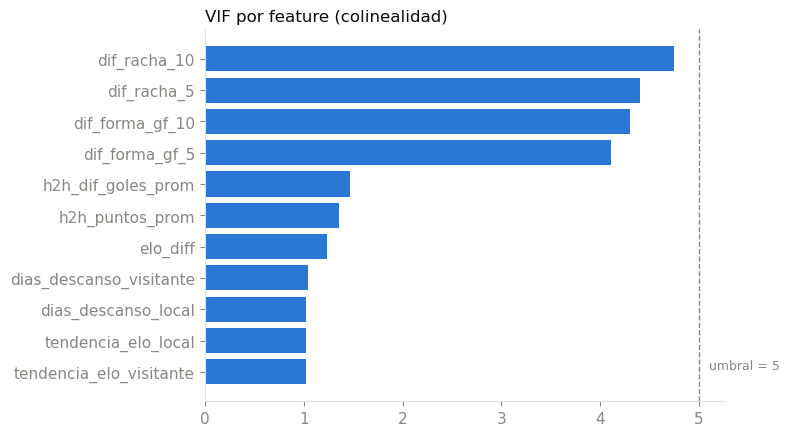

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

FEATURES_VIF = [
    "elo_diff", "tendencia_elo_local", "tendencia_elo_visitante",
    "dif_forma_gf_5", "dif_forma_gf_10", "dif_racha_5", "dif_racha_10",
    "dias_descanso_local", "dias_descanso_visitante",
    "h2h_puntos_prom", "h2h_dif_goles_prom",
]
X_vif = df_moderno[FEATURES_VIF].dropna().astype(float)
vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
    index=FEATURES_VIF,
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
colores_vif = [ROJO if v > 5 else AZUL for v in vif.values]
ax.barh(vif.index, vif.values, color=colores_vif)
ax.axvline(5, color=GRIS, linewidth=1, linestyle="--")
ax.text(5.1, 0, "umbral = 5", color=GRIS, fontsize=9, va="bottom")
ax.set_title("VIF por feature (colinealidad)", loc="left", fontsize=12, color=TINTA)
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

## 6. Elegir el modelo con evidencia, no con un solo torneo

Comparar GLM, LightGBM y XGBoost solo contra el Mundial 2026 no basta: un bootstrap sobre
esos 72 partidos da un intervalo de confianza de RMSE más ancho que la diferencia real entre
familias. Por eso la comparación se repite contra **5 Mundiales** (2010, 2014, 2018, 2022 y
2026), reentrenando cada vez solo con datos anteriores al inicio de ese torneo.

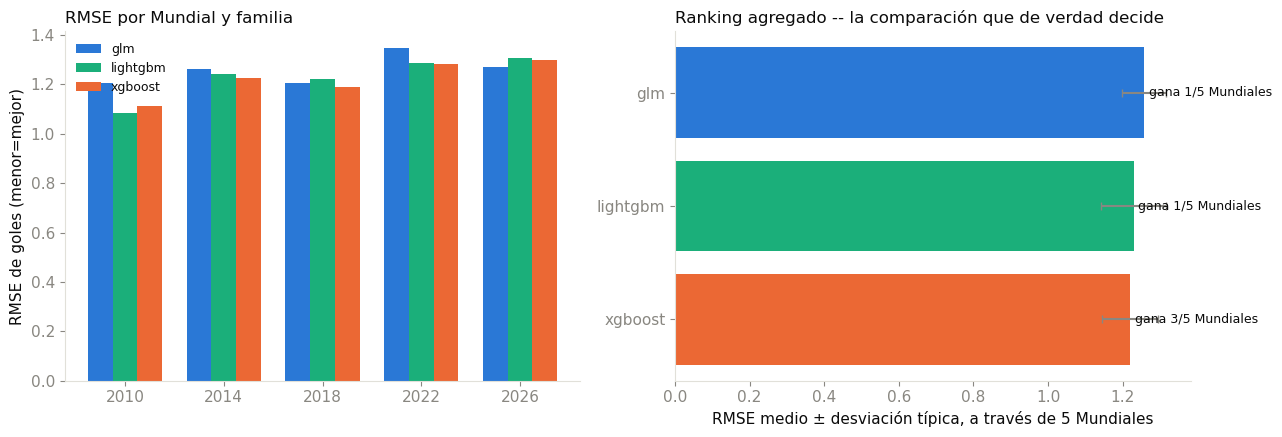

Familia con mejor RMSE medio a través de los 5 Mundiales: xgboost (1.2205 ± 0.0753, gana 3/5)


In [10]:
df_comparacion = pd.read_csv(DIR_RESULTS / "comparacion_modelos.csv")
df_resumen = pd.read_csv(DIR_RESULTS / "comparacion_resumen.csv").sort_values("rmse_medio")

COLOR_FAMILIA = {"glm": AZUL, "lightgbm": AQUA, "xgboost": NARANJA}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- RMSE por Mundial y familia ---
ax = axes[0]
mundiales = sorted(df_comparacion["mundial"].unique())
familias = list(COLOR_FAMILIA.keys())
ancho = 0.25
x = np.arange(len(mundiales))
for i, familia in enumerate(familias):
    valores = df_comparacion[df_comparacion["familia"] == familia].set_index("mundial").loc[mundiales, "rmse"]
    ax.bar(x + (i - 1) * ancho, valores.values, width=ancho, color=COLOR_FAMILIA[familia], label=familia)
ax.set_xticks(x)
ax.set_xticklabels(mundiales)
ax.set_ylabel("RMSE de goles (menor=mejor)")
ax.set_title("RMSE por Mundial y familia", loc="left", fontsize=12, color=TINTA)
ax.legend(frameon=False, fontsize=9)
limpiar_ejes(ax)

# --- Ranking agregado con barra de error (std) ---
ax = axes[1]
colores_resumen = [COLOR_FAMILIA[f] for f in df_resumen["familia"]]
ax.barh(df_resumen["familia"], df_resumen["rmse_medio"], xerr=df_resumen["rmse_std"],
        color=colores_resumen, error_kw=dict(ecolor=GRIS, capsize=3))
for i, (familia, rmse, veces) in enumerate(zip(df_resumen["familia"], df_resumen["rmse_medio"], df_resumen["veces_gana"])):
    ax.text(rmse + df_resumen["rmse_std"].max() * 0.15, i, f"gana {veces}/5 Mundiales",
            va="center", fontsize=9, color=TINTA)
ax.set_xlabel("RMSE medio ± desviación típica, a través de 5 Mundiales")
ax.set_title("Ranking agregado -- la comparación que de verdad decide", loc="left", fontsize=12, color=TINTA)
limpiar_ejes(ax)

plt.tight_layout()
plt.show()

ganador = df_resumen.iloc[0]
nombre_g, rmse_g, std_g, veces_g = ganador["familia"], ganador["rmse_medio"], ganador["rmse_std"], ganador["veces_gana"]
print(f"Familia con mejor RMSE medio a través de los 5 Mundiales: {nombre_g} "
      f"({rmse_g:.4f} ± {std_g:.4f}, gana {veces_g}/5)")

## 7. Calibración: cuando el modelo dice 70%, ¿acierta el 70% de las veces?

Un modelo bien calibrado no solo tiene que acertar el ganador -- cuando dice "70% de
probabilidad", eso debería cumplirse aproximadamente el 70% de las veces entre todos los
partidos donde dijo eso. Se compara sobre TODOS los partidos ya jugados del Mundial 2026
(fase de grupos + dieciseisavos).

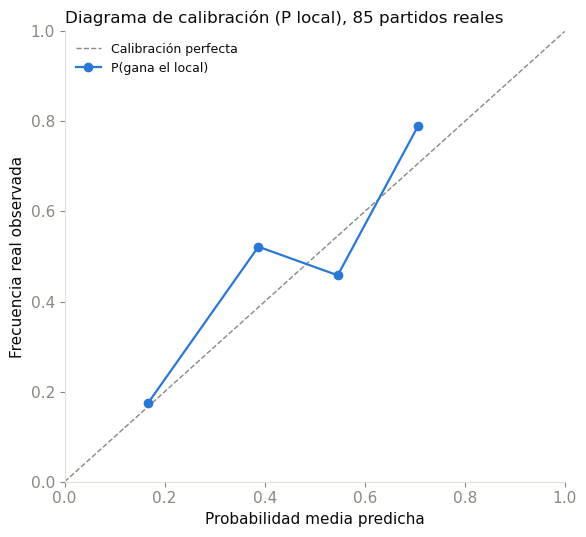

In [11]:
df_grupos_pred = pd.read_csv(DIR_RESULTS / "predicciones_fase_grupos.csv")
df_elim_pred = pd.read_csv(DIR_RESULTS / "predicciones_eliminatoria.csv")

def diagrama_calibracion(ax, prob_predicha, acierto, color, etiqueta, n_bins=4):
    bins = pd.qcut(prob_predicha, n_bins, duplicates="drop")
    resumen = pd.DataFrame({"prob": prob_predicha, "acierto": acierto, "bin": bins}).groupby("bin", observed=True).agg(
        prob_media=("prob", "mean"), frecuencia_real=("acierto", "mean"), n=("acierto", "size"))
    ax.plot(resumen["prob_media"], resumen["frecuencia_real"], "o-", color=color, linewidth=1.6, markersize=6, label=etiqueta)
    return resumen


prob_local = pd.concat([df_grupos_pred["prob_local"], df_elim_pred["prob_local"]], ignore_index=True)
acierto_local = pd.concat([
    df_grupos_pred["resultado_1x2_real"] == "LOCAL",
    df_elim_pred["resultado_1x2_real"] == "LOCAL",
], ignore_index=True)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot([0, 1], [0, 1], "--", color=GRIS, linewidth=1, label="Calibración perfecta")
diagrama_calibracion(ax, prob_local, acierto_local, AZUL, "P(gana el local)")
ax.set_xlabel("Probabilidad media predicha")
ax.set_ylabel("Frecuencia real observada")
ax.set_title("Diagrama de calibración (P local), 85 partidos reales", loc="left", fontsize=12, color=TINTA)
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

## 8. Precisión real hasta hoy, contra una baseline honesta

No basta con un número suelto -- hay que compararlo contra "predecir siempre lo más
probable a priori" (baseline ingenua), o cualquier acierto por encima del 50% suena mejor de
lo que es.

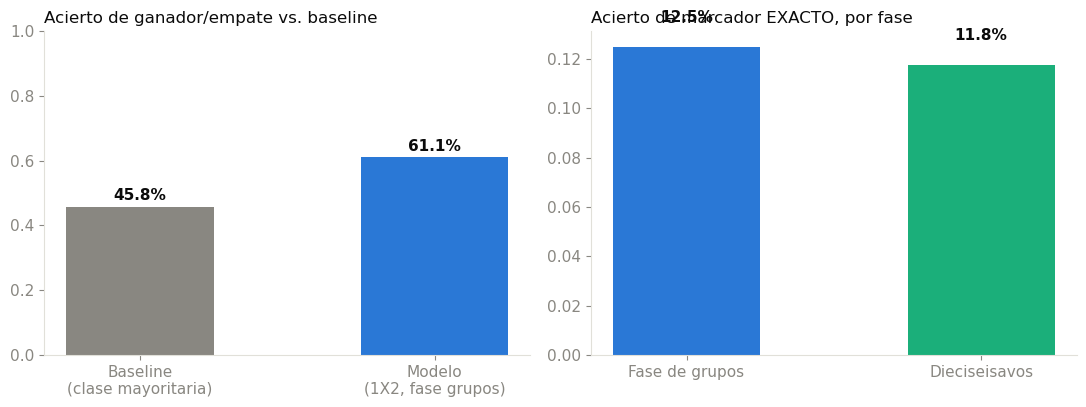

In [12]:
acierto_1x2_grupos = (df_grupos_pred["resultado_1x2_previsto"] == df_grupos_pred["resultado_1x2_real"]).mean()
acierto_marcador_grupos = (df_grupos_pred["marcador_previsto"] == df_grupos_pred["marcador_real"]).mean()
acierto_marcador_elim = (df_elim_pred["marcador_previsto"] == df_elim_pred["marcador_real_90min"]).mean()

baseline_ingenua = df_grupos_pred["resultado_1x2_real"].value_counts(normalize=True).max()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
etiquetas = ["Baseline\n(clase mayoritaria)", "Modelo\n(1X2, fase grupos)"]
valores = [baseline_ingenua, acierto_1x2_grupos]
ax.bar(etiquetas, valores, color=[GRIS, AZUL], width=0.5)
for i, v in enumerate(valores):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=11, fontweight="bold", color=TINTA)
ax.set_ylim(0, 1)
ax.set_title("Acierto de ganador/empate vs. baseline", loc="left", fontsize=12, color=TINTA)
limpiar_ejes(ax)

ax = axes[1]
etiquetas2 = ["Fase de grupos", "Dieciseisavos"]
valores2 = [acierto_marcador_grupos, acierto_marcador_elim]
ax.bar(etiquetas2, valores2, color=[AZUL, AQUA], width=0.5)
for i, v in enumerate(valores2):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=11, fontweight="bold", color=TINTA)
ax.set_title("Acierto de marcador EXACTO, por fase", loc="left", fontsize=12, color=TINTA)
limpiar_ejes(ax)

plt.tight_layout()
plt.show()

## 9. ¿Qué mira el modelo? Importancia de features (XGBoost)

Útil para desconfiar de un modelo que "acierta pero por razones raras" -- estas son las
features que más reducen el error al construir los árboles.

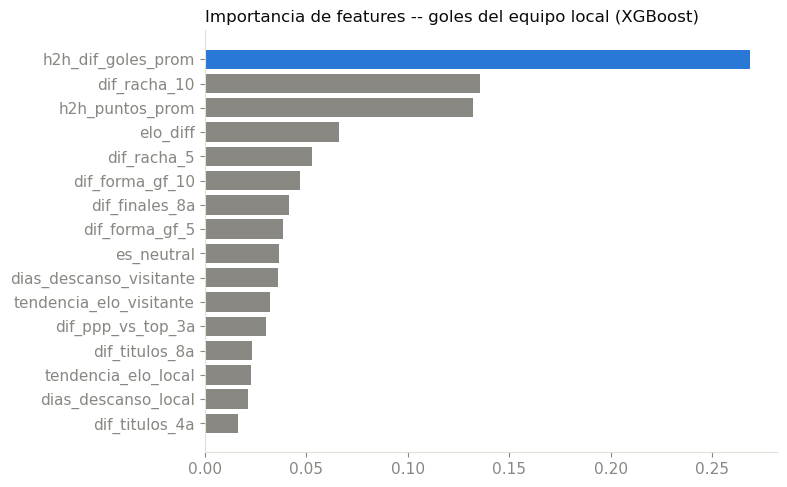

In [13]:
RUTA_CHECKPOINT_PRE_MUNDIAL = DIR_MODELOS / "checkpoints" / "pre_mundial"
modelo_local_pre = joblib.load(RUTA_CHECKPOINT_PRE_MUNDIAL / "modelo_goles_local.joblib")

# La lista de features se lee de los metadatos del checkpoint (no se hardcodea:
# si el pipeline añade features nuevas, esta sección se mantiene sincronizada sola).
import json as _json
with open(RUTA_CHECKPOINT_PRE_MUNDIAL / "metadata.json", encoding="utf-8") as _f:
    FEATURES_MODELO = _json.load(_f)["features"]

if hasattr(modelo_local_pre, "feature_importances_"):
    importancia = pd.Series(modelo_local_pre.feature_importances_, index=FEATURES_MODELO).sort_values()
    fig, ax = plt.subplots(figsize=(8, 5))
    colores_imp = [AZUL if v == importancia.max() else GRIS for v in importancia.values]
    ax.barh(importancia.index, importancia.values, color=colores_imp)
    ax.set_title("Importancia de features -- goles del equipo local (XGBoost)", loc="left", fontsize=12, color=TINTA)
    limpiar_ejes(ax)
    plt.tight_layout()
    plt.show()
else:
    print(f"El checkpoint pre_mundial es de familia '{type(modelo_local_pre).__name__}', "
          f"sin feature_importances_ directo (p.ej. un GLM) -- esta sección solo aplica a modelos de árboles.")

## 10. Predicción completa del torneo, 100% modelo (sin usar ningún resultado real de 2026)

Todo lo que sigue en las secciones 10-14 es **una única cadena de predicciones**, de principio
a fin: fase de grupos → clasificados → mejores terceros → sorteo de dieciseisavos → cuadro
completo hasta el campeón. En ningún punto se usa el resultado real de un partido de 2026 --
ni como dato de entrada (el checkpoint es el modelo tal como estaba el día antes de empezar el
Mundial, `pre_mundial`) ni para decidir quién avanza (eso también lo decide el modelo). Es la
respuesta a "¿qué diría el sistema si tuviera que predecir el torneo entero sin ver nada de lo
que ha pasado ya" -- distinto de la sección 16, que sí contrasta esto con la realidad.

**Fase de grupos**: marcador previsto para los 72 partidos. A propósito **no** se muestra aquí
una etiqueta de "quién gana" (LOCAL/EMPATE/VISITANTE): esa clasificación resume las tres
probabilidades acumuladas de la rejilla conjunta, y puede apuntar a un resultado distinto del
marcador más probable de esa misma rejilla (p.ej. "1-1" como marcador más probable, pero con
más masa de probabilidad acumulada del lado del local) -- correcto matemáticamente, pero
confuso de leer junto al marcador si no se explica, y sin utilidad real en fase de grupos: lo
único que importa para clasificar es la tabla de puntos, que sale directamente del marcador.
Esa etiqueta sí vuelve a partir de la sección 13, donde un empate no es una opción válida y
hace falta decidir quién avanza.

**`marcador_previsto` no es la única forma sensata de resumir la rejilla de probabilidad,
y esto importa para algo muy concreto**: si esto se usa para una porra que puntúa 3 por
acertar el ganador, 4 por acertar la diferencia de goles y 6 por el marcador exacto,
`marcador_previsto` (el argmax de probabilidad puntual) NO es necesariamente la apuesta que
más puntos espera dar -- son dos preguntas distintas. "¿Cuál es el marcador individual más
probable?" (lo que ya se muestra) y "¿qué apuesta maximiza los puntos esperados bajo ESTA
regla de puntuación?" (columna `apuesta_porra`, más abajo) pueden diferir, porque la regla de
puntos también premia acertar la diferencia de goles aunque el marcador exacto falle -- un
marcador con más masa de probabilidad acumulada en su misma diferencia puede ganar en valor
esperado aunque tenga menos probabilidad puntual que la moda.

In [14]:
import json

with open(DIR_RAW / "wc2026_calendario.json", encoding="utf-8") as f:
    calendario_2026 = json.load(f)["matches"]

# Mismo mapeo de nombres que en el Notebook 1 (el JSON y el histórico no
# siempre llaman igual a una selección).
MAPEO_NOMBRES_JSON = {"Bosnia & Herzegovina": "Bosnia and Herzegovina", "USA": "United States"}

partido_a_grupo = {}
for p in calendario_2026:
    if not p.get("group"):
        continue
    t1 = MAPEO_NOMBRES_JSON.get(p["team1"], p["team1"])
    t2 = MAPEO_NOMBRES_JSON.get(p["team2"], p["team2"])
    partido_a_grupo[(p["date"], frozenset([t1, t2]))] = p["group"]

df_grupos_pred["grupo"] = df_grupos_pred.apply(
    lambda r: partido_a_grupo.get((r["fecha"], frozenset([r["equipo_local"], r["equipo_visitante"]]))),
    axis=1,
)
assert df_grupos_pred["grupo"].notna().all(), "Algún partido de grupos no se pudo asignar a un grupo del Mundial"

# --- Apuesta óptima para una porra, no solo el marcador más probable -------------------
# Puntos de ejemplo (ajusta a las reglas de tu porra): 3 por acertar 1X2, 4 por acertar la
# diferencia de goles, 6 por el marcador exacto -- categorías EXCLUYENTES, se cobra la más
# alta que aplique, nunca se suman.
PUNTOS_GANADOR, PUNTOS_DIFERENCIA, PUNTOS_EXACTO = 3, 4, 6
RHO_PRODUCCION = -0.045  # mismo rho calibrado en el Notebook 4 sobre el entrenamiento pre-Mundial


def matriz_conjunta_dc(lam_a: float, lam_b: float, rho: float, max_goles: int = 8) -> np.ndarray:
    goles = np.arange(max_goles + 1)
    m = np.outer(poisson.pmf(goles, lam_a), poisson.pmf(goles, lam_b))
    m[0, 0] *= 1 - lam_a * lam_b * rho
    m[0, 1] *= 1 + lam_a * rho
    m[1, 0] *= 1 + lam_b * rho
    m[1, 1] *= 1 - rho
    m = np.clip(m, 0, None)
    return m / m.sum()


def mejor_apuesta_porra(matriz: np.ndarray, p_ganador: float = PUNTOS_GANADOR,
                          p_diferencia: float = PUNTOS_DIFERENCIA, p_exacto: float = PUNTOS_EXACTO) -> str:
    """Marcador que maximiza los puntos esperados bajo la regla de puntuación de la porra --
    no necesariamente el de mayor probabilidad puntual (`marcador_previsto`). Para cada
    candidato (i, j) se suma, sobre TODA la rejilla real (x, y): `p_exacto` si (x,y)==(i,j),
    si no `p_diferencia` si comparten diferencia de goles, si no `p_ganador` si comparten
    signo de la diferencia (mismo 1X2) -- exactamente las categorías de la porra, nunca
    combinadas."""
    n, m = matriz.shape
    X, Y = np.meshgrid(np.arange(n), np.arange(m), indexing="ij")
    diferencia_real = X - Y
    mejor_ev, mejor_marcador = -1.0, "0-0"
    for i in range(n):
        for j in range(m):
            es_exacto = (X == i) & (Y == j)
            es_diferencia = (diferencia_real == (i - j)) & ~es_exacto
            es_ganador = (np.sign(diferencia_real) == np.sign(i - j)) & (diferencia_real != (i - j))
            ev = (p_exacto * matriz[es_exacto].sum()
                  + p_diferencia * matriz[es_diferencia].sum()
                  + p_ganador * matriz[es_ganador].sum())
            if ev > mejor_ev:
                mejor_ev, mejor_marcador = ev, f"{i}-{j}"
    return mejor_marcador


def _apuesta_porra_fila(fila) -> str:
    matriz = matriz_conjunta_dc(fila["lambda_local"], fila["lambda_visitante"], RHO_PRODUCCION)
    return mejor_apuesta_porra(matriz)


df_grupos_pred["apuesta_porra"] = df_grupos_pred.apply(_apuesta_porra_fila, axis=1)

tabla_grupos_partidos = (
    df_grupos_pred.sort_values(["grupo", "fecha"])
    [["grupo", "fecha", "equipo_local", "equipo_visitante", "lambda_local", "lambda_visitante",
      "marcador_previsto", "apuesta_porra"]]
    .rename(columns={"lambda_local": "goles_esp_local", "lambda_visitante": "goles_esp_visitante"})
    .reset_index(drop=True)
)
tabla_grupos_partidos["goles_esp_local"] = tabla_grupos_partidos["goles_esp_local"].round(2)
tabla_grupos_partidos["goles_esp_visitante"] = tabla_grupos_partidos["goles_esp_visitante"].round(2)

n_diferentes = (tabla_grupos_partidos["marcador_previsto"] != tabla_grupos_partidos["apuesta_porra"]).sum()
print(f"{len(tabla_grupos_partidos)} partidos de fase de grupos -- marcador previsto por el "
      f"checkpoint pre-Mundial (día antes de empezar el torneo, sin ver ningún resultado de 2026).")
print("`goles_esp_*` son los goles esperados (lambda) que predice el modelo -- el marcador "
      "previsto es solo el entero mas probable de esa cifra continua, asi que dos partidos "
      "con el mismo '2-0' pueden reflejar niveles de dominio muy distintos (1.6 vs 0.9 no es "
      "lo mismo que 2.8 vs 0.5, aunque ambos redondeen al mismo marcador).")
print(f"`apuesta_porra` es la apuesta con más puntos esperados bajo 3/4/6 (ganador/diferencia/exacto) "
      f"-- difiere de `marcador_previsto` en {n_diferentes}/{len(tabla_grupos_partidos)} partidos.")


72 partidos de fase de grupos -- marcador previsto por el checkpoint pre-Mundial (día antes de empezar el torneo, sin ver ningún resultado de 2026).
`goles_esp_*` son los goles esperados (lambda) que predice el modelo -- el marcador previsto es solo el entero mas probable de esa cifra continua, asi que dos partidos con el mismo '2-0' pueden reflejar niveles de dominio muy distintos (1.6 vs 0.9 no es lo mismo que 2.8 vs 0.5, aunque ambos redondeen al mismo marcador).
`apuesta_porra` es la apuesta con más puntos esperados bajo 3/4/6 (ganador/diferencia/exacto) -- difiere de `marcador_previsto` en 21/72 partidos.


In [15]:
def _resaltar_apuesta_distinta(fila):
    estilos = [""] * len(fila)
    if fila["marcador_previsto"] != fila["apuesta_porra"]:
        estilos[fila.index.get_loc("apuesta_porra")] = f"color: {AZUL}; font-weight: bold"
    return estilos


(tabla_grupos_partidos.style
    .apply(_resaltar_apuesta_distinta, axis=1)
    .format({"goles_esp_local": "{:.2f}", "goles_esp_visitante": "{:.2f}"})
    .hide(axis="index"))


grupo,fecha,equipo_local,equipo_visitante,goles_esp_local,goles_esp_visitante,marcador_previsto,apuesta_porra
Group A,2026-06-11,South Korea,Czech Republic,1.36,1.09,1-1,1-0
Group A,2026-06-11,Mexico,South Africa,1.95,0.68,2-0,1-0
Group A,2026-06-18,Czech Republic,South Africa,1.66,0.86,1-0,1-0
Group A,2026-06-18,Mexico,South Korea,1.67,0.72,1-0,1-0
Group A,2026-06-24,Mexico,Czech Republic,1.93,0.73,1-0,1-0
Group A,2026-06-24,South Africa,South Korea,0.85,1.57,0-1,0-1
Group B,2026-06-12,Canada,Bosnia and Herzegovina,1.87,0.80,1-0,1-0
Group B,2026-06-13,Qatar,Switzerland,1.10,1.29,1-1,0-1
Group B,2026-06-18,Switzerland,Bosnia and Herzegovina,1.36,0.93,1-1,1-0
Group B,2026-06-18,Canada,Qatar,1.83,0.58,1-0,1-0


## 11. Clasificación prevista de cada grupo

De los marcadores de la sección 10 sale la tabla de cada grupo (3 puntos por victoria,
diferencia de goles y goles a favor como desempate -- una simplificación honesta: no
reproduce el desempate oficial de FIFA por enfrentamiento directo/fair play, que rara vez
hace falta pero puede cambiar un cruce puntual). El formato de 48 selecciones clasifica a
dieciseisavos a los dos primeros de cada grupo (24 plazas) más los **8 mejores terceros** de
los 12 grupos (sección 12) -- así que la 3ª plaza de cada grupo queda "pendiente" hasta
compararla con las demás.

In [16]:
def tabla_puntos_grupo(df_grupo: pd.DataFrame, col_marcador: str = "marcador_previsto") -> pd.DataFrame:
    """Pts/GF/GC/DG por selección a partir de una columna de marcador ('x-y'),
    ordenado por el criterio de desempate simplificado (Pts, DG, GF)."""
    equipos = sorted(set(df_grupo["equipo_local"]) | set(df_grupo["equipo_visitante"]))
    stats = {e: {"Pts": 0, "GF": 0, "GC": 0} for e in equipos}
    for _, fila in df_grupo.iterrows():
        gl, gv = map(int, fila[col_marcador].split("-"))
        el, ev = fila["equipo_local"], fila["equipo_visitante"]
        stats[el]["GF"] += gl; stats[el]["GC"] += gv
        stats[ev]["GF"] += gv; stats[ev]["GC"] += gl
        if gl > gv:
            stats[el]["Pts"] += 3
        elif gl < gv:
            stats[ev]["Pts"] += 3
        else:
            stats[el]["Pts"] += 1
            stats[ev]["Pts"] += 1
    tabla = pd.DataFrame(stats).T
    tabla["DG"] = tabla["GF"] - tabla["GC"]
    return tabla.sort_values(["Pts", "DG", "GF"], ascending=False)


standings_grupos = {
    grupo: tabla_puntos_grupo(tabla_grupos_partidos[tabla_grupos_partidos["grupo"] == grupo])
    for grupo in sorted(tabla_grupos_partidos["grupo"].unique())
}

ESTADO_POR_POSICION = {1: "1º -- clasifica", 2: "2º -- clasifica", 3: "3º -- pendiente", 4: "4º -- eliminado"}

df_clasificacion = pd.DataFrame([
    {"grupo": grupo, "pos": pos, "equipo": equipo,
     "Pts": int(tabla.loc[equipo, "Pts"]), "DG": int(tabla.loc[equipo, "DG"]), "GF": int(tabla.loc[equipo, "GF"]),
     "estado": ESTADO_POR_POSICION[pos]}
    for grupo, tabla in standings_grupos.items()
    for pos, equipo in enumerate(tabla.index, start=1)
])
print(f"{len(standings_grupos)} grupos -- 24 plazas automáticas (1º y 2º) + 8 mejores terceros por decidir (sección 12).")

12 grupos -- 24 plazas automáticas (1º y 2º) + 8 mejores terceros por decidir (sección 12).


In [17]:
COLOR_ESTADO = {
    "1º -- clasifica": VERDE, "2º -- clasifica": VERDE,
    "3º -- pendiente": AMARILLO, "4º -- eliminado": ROJO,
}


def _resaltar_estado_clasificacion(fila):
    estilos = [""] * len(fila)
    estilos[fila.index.get_loc("estado")] = f"color: {COLOR_ESTADO[fila['estado']]}; font-weight: bold"
    return estilos


df_clasificacion.style.apply(_resaltar_estado_clasificacion, axis=1).hide(axis="index")

grupo,pos,equipo,Pts,DG,GF,estado
Group A,1,Mexico,9,4,4,1º -- clasifica
Group A,2,Czech Republic,4,0,2,2º -- clasifica
Group A,3,South Korea,4,0,2,3º -- pendiente
Group A,4,South Africa,0,-4,0,4º -- eliminado
Group B,1,Canada,9,3,3,1º -- clasifica
Group B,2,Bosnia and Herzegovina,2,-1,2,2º -- clasifica
Group B,3,Qatar,2,-1,2,3º -- pendiente
Group B,4,Switzerland,2,-1,2,4º -- eliminado
Group C,1,Brazil,9,4,4,1º -- clasifica
Group C,2,Morocco,6,2,3,2º -- clasifica


## 11b. Grupo a grupo: puntos previstos contra puntos reales

La vista más exigente de la fase de grupos: para cada selección, los puntos que el modelo
le daba (sumando sus 1X2 previstos partido a partido, a ciegas) contra los que de verdad
sacó. Donde el punto azul y el gris coinciden, el modelo clavó al equipo; las distancias
grandes son las sorpresas del torneo. Debajo, el acierto desglosado por jornada de grupos
y por ronda eliminatoria — la trayectoria completa del modelo a lo largo del torneo.

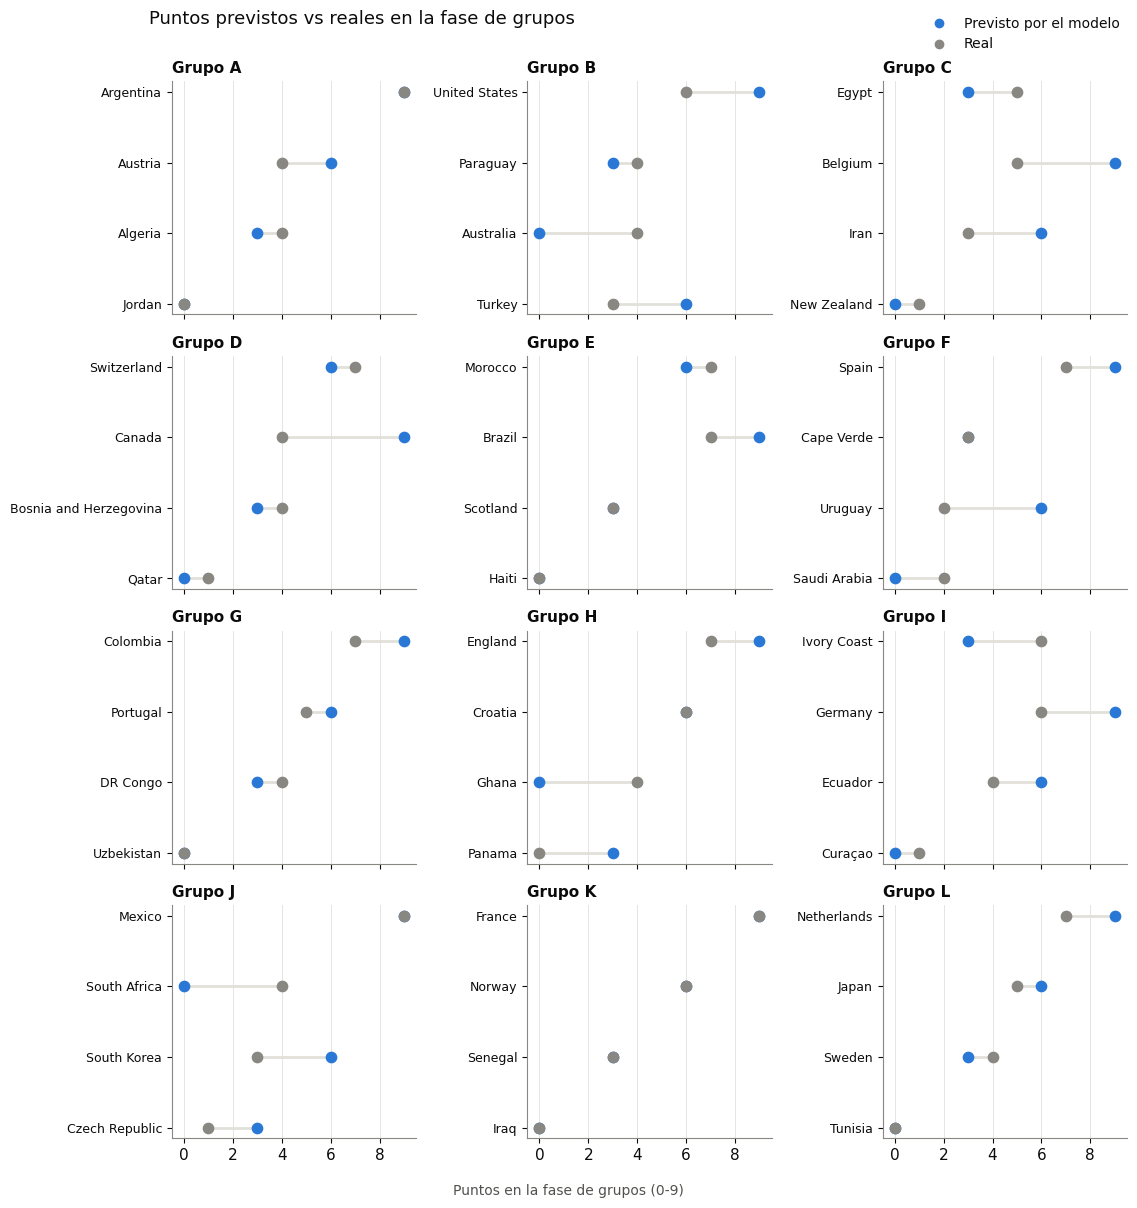

Selecciones con los puntos EXACTOS clavados: 13/48 (27%); error medio |previsto-real| = 1.62 puntos.


In [18]:
import networkx as nx

df_g = pd.read_csv(DIR_RESULTS / "predicciones_fase_grupos.csv", parse_dates=["fecha"])

# Reconstruir los 12 grupos desde los propios partidos (camarillas de 4)
grafo = nx.Graph()
for _, f in df_g.iterrows():
    grafo.add_edge(f["equipo_local"], f["equipo_visitante"])
camarillas = [c for c in nx.enumerate_all_cliques(grafo) if len(c) == 4]
usados, grupos = set(), []
for c in camarillas:
    if not (set(c) & usados):
        grupos.append(sorted(c)); usados.update(c)
grupos = sorted(grupos, key=lambda g: g[0])

def puntos_por_equipo(df, col_resultado):
    pts = {}
    for _, f in df.iterrows():
        r = f[col_resultado]
        pl, pv = (3, 0) if r == "LOCAL" else ((0, 3) if r == "VISITANTE" else (1, 1))
        pts[f["equipo_local"]] = pts.get(f["equipo_local"], 0) + pl
        pts[f["equipo_visitante"]] = pts.get(f["equipo_visitante"], 0) + pv
    return pts

pts_prev = puntos_por_equipo(df_g, "resultado_1x2_previsto")
pts_real = puntos_por_equipo(df_g, "resultado_1x2_real")

fig, axes = plt.subplots(4, 3, figsize=(11.5, 12), sharex=True)
for k, (ax, grupo) in enumerate(zip(axes.ravel(), grupos)):
    equipos = sorted(grupo, key=lambda e: pts_real.get(e, 0))
    for y, eq in enumerate(equipos):
        pr, re = pts_prev.get(eq, 0), pts_real.get(eq, 0)
        ax.plot([pr, re], [y, y], color=GRIS_CLARO, linewidth=2, zorder=1)
        ax.scatter([pr], [y], s=55, color=AZUL, zorder=2)
        ax.scatter([re], [y], s=55, color=GRIS, zorder=2)
    ax.set_yticks(range(len(equipos)), equipos, fontsize=9)
    ax.set_title(f"Grupo {chr(65 + k)}", loc="left", fontsize=11, color=TINTA, fontweight="bold")
    ax.set_xlim(-0.5, 9.5)
    ax.grid(axis="x", color=GRIS_CLARO, linewidth=0.6)
    ax.set_axisbelow(True)
from matplotlib.lines import Line2D
fig.legend(handles=[
    Line2D([], [], marker="o", linestyle="", color=AZUL, label="Previsto por el modelo"),
    Line2D([], [], marker="o", linestyle="", color=GRIS, label="Real"),
], loc="upper right", frameon=False, fontsize=10, bbox_to_anchor=(0.99, 1.005))
fig.suptitle("Puntos previstos vs reales en la fase de grupos", fontsize=13, color=TINTA, y=1.0, x=0.32)
fig.supxlabel("Puntos en la fase de grupos (0-9)", fontsize=10, color="#52514e")
plt.tight_layout()
plt.show()

clavados = sum(1 for eq in pts_real if pts_prev.get(eq, 0) == pts_real[eq])
print(f"Selecciones con los puntos EXACTOS clavados: {clavados}/{len(pts_real)} "
      f"({clavados / len(pts_real):.0%}); error medio |previsto-real| = "
      f"{np.mean([abs(pts_prev.get(e, 0) - pts_real[e]) for e in pts_real]):.2f} puntos.")

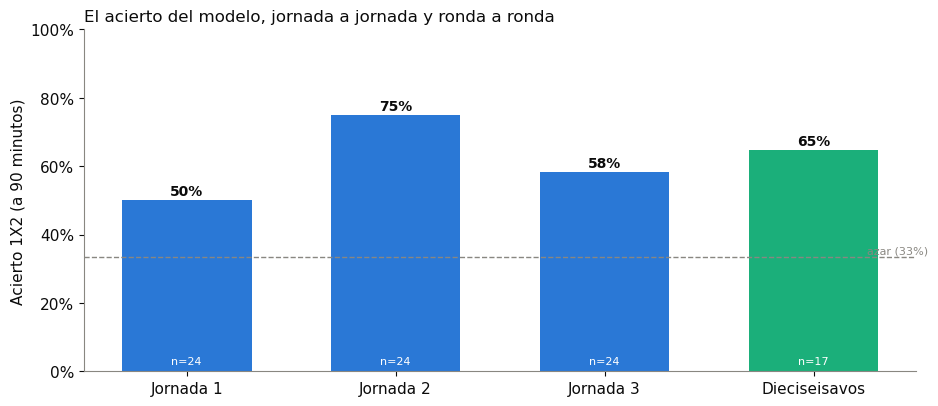

In [19]:
# Acierto por jornada de grupos (1a/2a/3a aparición de cada pareja) y por ronda KO
df_g_ord = df_g.sort_values("fecha").copy()
apariciones = {}
jornadas = []
for _, f in df_g_ord.iterrows():
    n = max(apariciones.get(f["equipo_local"], 0), apariciones.get(f["equipo_visitante"], 0)) + 1
    jornadas.append(min(n, 3))
    for eq in (f["equipo_local"], f["equipo_visitante"]):
        apariciones[eq] = apariciones.get(eq, 0) + 1
df_g_ord["jornada"] = jornadas

df_e = pd.read_csv(DIR_RESULTS / "predicciones_eliminatoria.csv", parse_dates=["fecha"])
df_e = df_e[df_e["resultado_1x2_real"].notna()]
NOMBRES_RONDA = {1: "Dieciseisavos", 2: "Octavos", 3: "Cuartos", 4: "Semifinales", 5: "Final"}

etiquetas, valores, ns = [], [], []
for j, g in df_g_ord.groupby("jornada"):
    etiquetas.append(f"Jornada {j}")
    valores.append((g["resultado_1x2_previsto"] == g["resultado_1x2_real"]).mean())
    ns.append(len(g))
ETIQUETA_1X2 = np.array(["LOCAL", "EMPATE", "VISITANTE"])
df_e["previsto_1x2"] = ETIQUETA_1X2[
    df_e[["prob_local", "prob_empate", "prob_visitante"]].to_numpy().argmax(axis=1)]
for r, g in df_e.groupby("ronda"):
    etiquetas.append(NOMBRES_RONDA.get(r, f"Ronda {r}"))
    valores.append((g["previsto_1x2"] == g["resultado_1x2_real"]).mean())
    ns.append(len(g))

fig, ax = plt.subplots(figsize=(9.5, 4.2))
colores = [AZUL] * 3 + [AQUA] * (len(etiquetas) - 3)
barras = ax.bar(etiquetas, valores, color=colores, width=0.62)
for x, (v, n) in enumerate(zip(valores, ns)):
    if not np.isnan(v):
        ax.text(x, v + 0.015, f"{v:.0%}", ha="center", fontsize=10, fontweight="bold", color=TINTA)
        ax.text(x, 0.02, f"n={n}", ha="center", fontsize=8, color="white")
ax.axhline(1/3, color=GRIS, linestyle="--", linewidth=1)
ax.text(len(etiquetas) - 0.45, 1/3 + 0.012, "azar (33%)", fontsize=8, color=GRIS, ha="right")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel("Acierto 1X2 (a 90 minutos)")
ax.set_title("El acierto del modelo, jornada a jornada y ronda a ronda", loc="left", fontsize=12, color=TINTA)
plt.tight_layout()
plt.show()

## 12. Los mejores terceros

Los 12 equipos en 3ª posición se ordenan entre sí por el mismo criterio (Pts, DG, GF) y los
8 mejores completan las 32 plazas de dieciseisavos -- los otros 4 quedan eliminados a pesar
de no haber acabado últimos en su grupo.

In [20]:
df_terceros = pd.DataFrame([
    {"grupo": grupo.replace("Group ", ""), "equipo": tabla.index[2],
     "Pts": int(tabla.loc[tabla.index[2], "Pts"]),
     "DG": int(tabla.loc[tabla.index[2], "DG"]),
     "GF": int(tabla.loc[tabla.index[2], "GF"])}
    for grupo, tabla in standings_grupos.items()
]).sort_values(["Pts", "DG", "GF"], ascending=False).reset_index(drop=True)

df_terceros["clasifica"] = df_terceros.index < 8
LETRAS_MEJORES_TERCEROS = set(df_terceros.loc[df_terceros["clasifica"], "grupo"])
TERCERO_POR_GRUPO = dict(zip(df_terceros["grupo"], df_terceros["equipo"]))

print(f"Mejores 8 terceros: {', '.join(df_terceros.loc[df_terceros['clasifica'], 'equipo'])}")

Mejores 8 terceros: South Korea, Iran, Norway, Austria, Ivory Coast, Scotland, Sweden, Panama


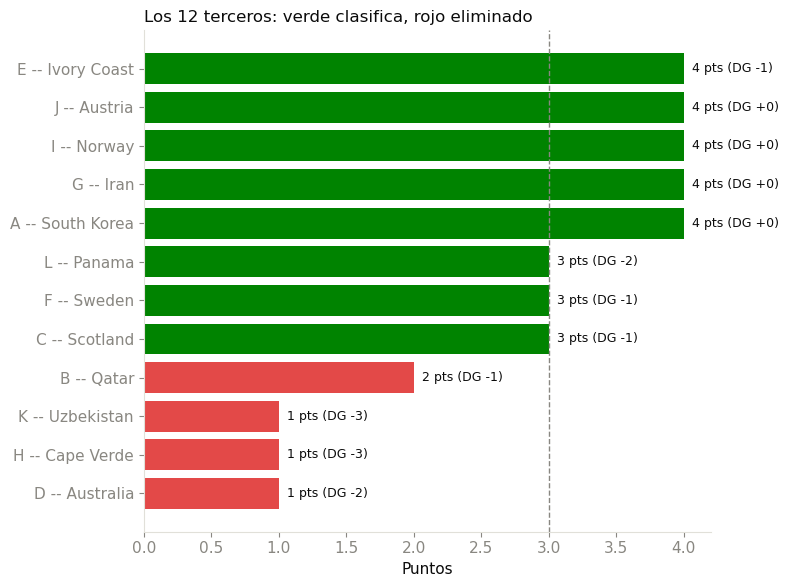

In [21]:
orden = df_terceros.sort_values("Pts")
colores_terceros = [VERDE if c else ROJO for c in orden["clasifica"]]
etiquetas_terceros = [f"{g} -- {e}" for g, e in zip(orden["grupo"], orden["equipo"])]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(etiquetas_terceros, orden["Pts"], color=colores_terceros)
for i, (pts, dg) in enumerate(zip(orden["Pts"], orden["DG"])):
    ax.text(pts + 0.06, i, f"{pts} pts (DG {dg:+d})", va="center", fontsize=9, color=TINTA)
ax.axvline(df_terceros.loc[7, "Pts"], color=GRIS, linewidth=1, linestyle="--")
ax.set_xlabel("Puntos")
ax.set_title("Los 12 terceros: verde clasifica, rojo eliminado", loc="left", fontsize=12, color=TINTA)
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

## 13. El sorteo de dieciseisavos

El cruce de cada plaza de dieciseisavos está fijado por FIFA de antemano por POSICIÓN, no
por selección -- p.ej. "2º de A vs 2º de B", o "1º de E vs el mejor situado de los terceros
de A/B/C/D/F que clasifique". Esa plantilla se descarga de la versión de
`openfootball/worldcup.json` anterior al inicio del torneo (fijada a un commit concreto, para
que no cambie si se vuelve a ejecutar este notebook más adelante) -- los cruces "1X"/"2X" se
resuelven directamente contra la clasificación de la sección 11, y los 8 huecos de "3º de
[grupos]" se resuelven como un problema de asignación: cada uno de los 8 mejores terceros
(sección 12) tiene que encajar en un hueco cuyo conjunto de grupos permitidos incluya el suyo
(por diseño de FIFA, con 8 clasificados siempre hay al menos una asignación válida; si hay
más de una, aquí se toma la primera que se encuentra, no necesariamente la que usaría FIFA en
caso de empate en esa elección -- no cambia el marcador de ningún partido, solo qué asiento
físico del cuadro ocupa cada equipo).

In [22]:
import re

import requests

# Commit anterior al inicio del torneo -- en cuanto se juega la fase de grupos, el propio
# `openfootball/worldcup.json` va sustituyendo estos códigos de posición por selecciones
# reales, así que solo una versión fijada en el tiempo conserva la plantilla original.
URL_PLANTILLA_BRACKET = "https://raw.githubusercontent.com/openfootball/worldcup.json/326b3f85/2026/worldcup.json"

respuesta = requests.get(URL_PLANTILLA_BRACKET, timeout=30)
respuesta.raise_for_status()
plantilla_bracket = {i: partido for i, partido in enumerate(respuesta.json()["matches"], start=1)}
print(f"Plantilla de cuadro descargada: {len(plantilla_bracket)} partidos (dieciseisavos-final = 73-104).")


def _parsear_slot(codigo: str):
    """'2B' -> 2º de B; '3A/C/F' -> el mejor tercero clasificado entre A, C o F; 'W74'/'L101' ->
    referencia a un partido anterior (se resuelve más adelante, en la cascada de la sección 14)."""
    m = re.match(r"^(\d)([A-L])$", codigo)
    if m:
        return ("auto", int(m.group(1)), m.group(2))
    m = re.match(r"^3([A-L](?:/[A-L])*)$", codigo)
    if m:
        return ("tercero", set(m.group(1).split("/")))
    m = re.match(r"^([WL])(\d+)$", codigo)
    if m:
        return ("ref", m.group(1), int(m.group(2)))
    raise ValueError(f"Código de slot no reconocido: {codigo!r}")


slots_bracket = {
    num: {
        "a": _parsear_slot(partido["team1"]), "b": _parsear_slot(partido["team2"]),
        "fecha": pd.Timestamp(partido["date"]), "sede": partido["ground"],
    }
    for num, partido in plantilla_bracket.items() if num >= 73
}

# --- Resolver los 8 huecos de "3º de [grupos]" como una asignación biyectiva ---
huecos_terceros = {
    num: (s["a"][1] if s["a"][0] == "tercero" else s["b"][1])
    for num, s in slots_bracket.items() if s["a"][0] == "tercero" or s["b"][0] == "tercero"
}


def _asignar_terceros(letras: list[str], huecos: dict) -> dict:
    nums = list(huecos.keys())

    def backtrack(i: int, usados: set) -> dict | None:
        if i == len(letras):
            return {}
        for num in nums:
            if num in usados or letras[i] not in huecos[num]:
                continue
            usados.add(num)
            resto = backtrack(i + 1, usados)
            if resto is not None:
                resto[num] = letras[i]
                return resto
            usados.remove(num)
        return None

    return backtrack(0, set())


asignacion_terceros = _asignar_terceros(sorted(LETRAS_MEJORES_TERCEROS), huecos_terceros)
assert asignacion_terceros is not None, "No se encontró una asignación válida de terceros a huecos del sorteo"

Plantilla de cuadro descargada: 104 partidos (dieciseisavos-final = 73-104).


In [23]:
primeros_grupo = {grupo.replace("Group ", ""): tabla.index[0] for grupo, tabla in standings_grupos.items()}
segundos_grupo = {grupo.replace("Group ", ""): tabla.index[1] for grupo, tabla in standings_grupos.items()}


def _resolver_lado_r32(slot_lado, num: int) -> str:
    tipo = slot_lado[0]
    if tipo == "auto":
        _, posicion, letra = slot_lado
        return primeros_grupo[letra] if posicion == 1 else segundos_grupo[letra]
    return TERCERO_POR_GRUPO[asignacion_terceros[num]]


df_sorteo_r32 = pd.DataFrame([
    {"num": num, "fecha": s["fecha"].date(), "equipo_a": _resolver_lado_r32(s["a"], num),
     "equipo_b": _resolver_lado_r32(s["b"], num), "sede": s["sede"]}
    for num, s in slots_bracket.items() if num <= 88
]).sort_values("num").reset_index(drop=True)

print("Los 16 cruces de dieciseisavos, resueltos a partir de la clasificación 100% prevista:")
df_sorteo_r32[["fecha", "equipo_a", "equipo_b", "sede"]].style.hide(axis="index")

Los 16 cruces de dieciseisavos, resueltos a partir de la clasificación 100% prevista:


fecha,equipo_a,equipo_b,sede
2026-06-28,Czech Republic,Bosnia and Herzegovina,Los Angeles (Inglewood)
2026-06-29,Germany,South Korea,Boston (Foxborough)
2026-06-29,Netherlands,Morocco,Monterrey (Guadalupe)
2026-06-29,Brazil,Japan,Houston
2026-06-30,France,Scotland,New York/New Jersey (East Rutherford)
2026-06-30,Ecuador,Senegal,Dallas (Arlington)
2026-06-30,Mexico,Ivory Coast,Mexico City
2026-07-01,England,Norway,Atlanta
2026-07-01,Turkey,Sweden,San Francisco Bay Area (Santa Clara)
2026-07-01,Belgium,Austria,Seattle


## 14. Cuadro eliminatorio 100% previsto

De dieciseisavos a la final, con el mismo checkpoint `pre_mundial` y la misma lógica de
decisión que el resto del proyecto (Notebook 4, sección 4.6): quién avanza se decide
**siempre** comparando la probabilidad acumulada de cada lado en la matriz de probabilidad
conjunta, nunca el marcador puntual de cada lambda por separado. Elo/forma/racha de cada
selección se congelan en su última cifra real de antes del torneo (no se actualizan ronda a
ronda -- el mismo supuesto que ya usa la simulación Montecarlo del Notebook 4); lo único que
sí avanza con cada cruce son los días de descanso, encadenados desde la fecha de cada
partido previsto.

In [24]:
metadata_pre_mundial = json.loads((RUTA_CHECKPOINT_PRE_MUNDIAL / "metadata.json").read_text())
FECHA_CORTE_PRE_MUNDIAL = pd.Timestamp(metadata_pre_mundial["ultima_fecha_entrenamiento"])
modelo_visitante_pre = joblib.load(RUTA_CHECKPOINT_PRE_MUNDIAL / "modelo_goles_visitante.joblib")

df_train_pre_mundial = df_features[(df_features["fecha"] <= FECHA_CORTE_PRE_MUNDIAL) & df_features["jugado"]].copy()
print(f"Snapshot congelado al {FECHA_CORTE_PRE_MUNDIAL.date()} -- {len(df_train_pre_mundial):,} partidos de entrenamiento.")


def snapshot_equipo(equipo: str, df_train: pd.DataFrame) -> dict:
    es_local = df_train["equipo_local"] == equipo
    es_visitante = df_train["equipo_visitante"] == equipo
    ultima_local = df_train.loc[es_local, "fecha"].max() if es_local.any() else pd.Timestamp.min
    ultima_visitante = df_train.loc[es_visitante, "fecha"].max() if es_visitante.any() else pd.Timestamp.min
    if ultima_local >= ultima_visitante:
        fila = df_train.loc[es_local].sort_values("fecha").iloc[-1]; sufijo = "_local"
    else:
        fila = df_train.loc[es_visitante].sort_values("fecha").iloc[-1]; sufijo = "_visitante"
    return {
        "elo": fila[f"elo_actual{sufijo}"], "tendencia_elo": fila[f"tendencia_elo{sufijo}"],
        "forma_gf_5": fila[f"prom_gf_5{sufijo}"], "forma_gf_10": fila[f"prom_gf_10{sufijo}"],
        "racha_5": fila[f"racha_puntos_5{sufijo}"], "racha_10": fila[f"racha_puntos_10{sufijo}"],
        "titulos_8a": fila[f"titulos_8a{sufijo}"], "titulos_4a": fila[f"titulos_4a{sufijo}"],
        "finales_8a": fila[f"finales_8a{sufijo}"], "ppp_vs_top_3a": fila[f"ppp_vs_top_3a{sufijo}"],
        "ultima_fecha": max(ultima_local, ultima_visitante),
    }


def calcular_h2h(equipos: list[str], df_train: pd.DataFrame) -> dict:
    resultados = {}
    for i, x in enumerate(equipos):
        for y in equipos[i + 1:]:
            previos = df_train[((df_train["equipo_local"] == x) & (df_train["equipo_visitante"] == y))
                                | ((df_train["equipo_local"] == y) & (df_train["equipo_visitante"] == x))]
            if previos.empty:
                resultados[(x, y)] = (1.0, 0.0); resultados[(y, x)] = (1.0, 0.0); continue
            px, py, dx, dy = [], [], [], []
            for f in previos.itertuples(index=False):
                gx, gy = (f.goles_local, f.goles_visitante) if f.equipo_local == x else (f.goles_visitante, f.goles_local)
                px.append(3 if gx > gy else (1 if gx == gy else 0)); py.append(3 if gy > gx else (1 if gx == gy else 0))
                dx.append(gx - gy); dy.append(gy - gx)
            resultados[(x, y)] = (float(np.mean(px)), float(np.mean(dx)))
            resultados[(y, x)] = (float(np.mean(py)), float(np.mean(dy)))
    return resultados


equipos_clasificados = set(primeros_grupo.values()) | set(segundos_grupo.values()) | set(TERCERO_POR_GRUPO[l] for l in LETRAS_MEJORES_TERCEROS)
assert len(equipos_clasificados) == 32, f"Se esperaban 32 clasificados, hay {len(equipos_clasificados)}"

snapshots_pre_mundial = {equipo: snapshot_equipo(equipo, df_train_pre_mundial) for equipo in equipos_clasificados}
h2h_pre_mundial = calcular_h2h(sorted(equipos_clasificados), df_train_pre_mundial)


def log_verosimilitud_dixon_coles(rho, lam, mu, x, y):
    ll = poisson.logpmf(x, lam) + poisson.logpmf(y, mu)
    m00, m01, m10, m11 = (x == 0) & (y == 0), (x == 0) & (y == 1), (x == 1) & (y == 0), (x == 1) & (y == 1)
    ll[m00] += np.log(np.clip(1 - lam[m00] * mu[m00] * rho, 1e-10, None))
    ll[m01] += np.log(np.clip(1 + lam[m01] * rho, 1e-10, None))
    ll[m10] += np.log(np.clip(1 + mu[m10] * rho, 1e-10, None))
    ll[m11] += np.log(np.clip(1 - rho, 1e-10, None))
    return ll.sum()


X_train_pre_mundial = df_train_pre_mundial[FEATURES_MODELO]
lam_hist = np.clip(modelo_local_pre.predict(X_train_pre_mundial), 0.01, None)
mu_hist = np.clip(modelo_visitante_pre.predict(X_train_pre_mundial), 0.01, None)
candidatos_rho = np.linspace(-0.3, 0.3, 61)
log_vero = [log_verosimilitud_dixon_coles(r, lam_hist, mu_hist, df_train_pre_mundial["goles_local"].to_numpy(),
                                            df_train_pre_mundial["goles_visitante"].to_numpy()) for r in candidatos_rho]
RHO_PRE_MUNDIAL = float(candidatos_rho[np.argmax(log_vero)])
print(f"32 selecciones clasificadas -- rho de Dixon-Coles (checkpoint pre-Mundial): {RHO_PRE_MUNDIAL:.4f}")

Snapshot congelado al 2026-06-10 -- 49,403 partidos de entrenamiento.


32 selecciones clasificadas -- rho de Dixon-Coles (checkpoint pre-Mundial): -0.0400


In [25]:
CIUDAD_A_PAIS_MUNDIAL_2026 = {
    "Mexico City": "Mexico", "Zapopan": "Mexico", "Guadalupe": "Mexico",
    "Toronto": "Canada", "Vancouver": "Canada",
    "Inglewood": "United States", "Santa Clara": "United States",
    "East Rutherford": "United States", "Foxborough": "United States",
    "Philadelphia": "United States", "Houston": "United States",
    "Seattle": "United States", "Atlanta": "United States",
    "Miami Gardens": "United States", "Arlington": "United States",
    "Kansas City": "United States",
}


def _ciudad_desde_sede(sede: str) -> str:
    return sede.split("(")[1].rstrip(")") if "(" in sede else sede


def matriz_probabilidad_conjunta(lam_a: float, lam_b: float, max_goles: int = 8) -> np.ndarray:
    goles = np.arange(max_goles + 1)
    matriz = np.outer(poisson.pmf(goles, lam_a), poisson.pmf(goles, lam_b))
    matriz[0, 0] *= 1 - lam_a * lam_b * RHO_PRE_MUNDIAL
    matriz[0, 1] *= 1 + lam_a * RHO_PRE_MUNDIAL
    matriz[1, 0] *= 1 + lam_b * RHO_PRE_MUNDIAL
    matriz[1, 1] *= 1 - RHO_PRE_MUNDIAL
    matriz = np.clip(matriz, 0, None)
    return matriz / matriz.sum()


def construir_features_cruce(equipo_a: str, equipo_b: str, fecha: pd.Timestamp, es_neutral: bool,
                               ultimo_partido: dict) -> pd.DataFrame:
    snap_a, snap_b = snapshots_pre_mundial[equipo_a], snapshots_pre_mundial[equipo_b]
    h2h_puntos, h2h_dif_goles = h2h_pre_mundial[(equipo_a, equipo_b)]
    return pd.DataFrame([{
        "elo_diff": snap_a["elo"] - snap_b["elo"],
        "tendencia_elo_local": snap_a["tendencia_elo"], "tendencia_elo_visitante": snap_b["tendencia_elo"],
        "dif_forma_gf_5": snap_a["forma_gf_5"] - snap_b["forma_gf_5"],
        "dif_forma_gf_10": snap_a["forma_gf_10"] - snap_b["forma_gf_10"],
        "dif_racha_5": snap_a["racha_5"] - snap_b["racha_5"], "dif_racha_10": snap_a["racha_10"] - snap_b["racha_10"],
        "dias_descanso_local": (fecha - ultimo_partido[equipo_a]).days,
        "dias_descanso_visitante": (fecha - ultimo_partido[equipo_b]).days,
        "es_neutral": es_neutral, "h2h_puntos_prom": h2h_puntos, "h2h_dif_goles_prom": h2h_dif_goles,
        "dif_titulos_8a": snap_a["titulos_8a"] - snap_b["titulos_8a"],
        "dif_titulos_4a": snap_a["titulos_4a"] - snap_b["titulos_4a"],
        "dif_finales_8a": snap_a["finales_8a"] - snap_b["finales_8a"],
        "dif_ppp_vs_top_3a": snap_a["ppp_vs_top_3a"] - snap_b["ppp_vs_top_3a"],
    }])[FEATURES_MODELO]


def resolver_cruce(equipo_a: str, equipo_b: str, fecha: pd.Timestamp, sede: str, ultimo_partido: dict) -> dict:
    """Decide quien avanza comparando la probabilidad acumulada de cada lado en la matriz
    conjunta (nunca el marcador puntual) -- mismo criterio que `resolver_eliminatoria` en el
    Notebook 4 (seccion 4.6). Devuelve tambien las lambda: el marcador es solo el entero mas
    probable de esa cifra continua, y dos cruces con el mismo marcador pueden reflejar
    niveles de dominio muy distintos si no se muestra la lambda al lado."""
    pais_sede = CIUDAD_A_PAIS_MUNDIAL_2026[_ciudad_desde_sede(sede)]
    if equipo_b == pais_sede and equipo_a != pais_sede:
        equipo_a, equipo_b = equipo_b, equipo_a
    es_neutral = equipo_a != pais_sede

    X = construir_features_cruce(equipo_a, equipo_b, fecha, es_neutral, ultimo_partido)
    lam_a = float(np.clip(modelo_local_pre.predict(X), 0.01, None)[0])
    lam_b = float(np.clip(modelo_visitante_pre.predict(X), 0.01, None)[0])
    matriz = matriz_probabilidad_conjunta(lam_a, lam_b)
    fila, col = np.unravel_index(np.argmax(matriz), matriz.shape)
    prob_a, prob_b = np.tril(matriz, -1).sum(), np.triu(matriz, 1).sum()
    ganador = equipo_a if prob_a >= prob_b else equipo_b
    perdedor = equipo_b if ganador == equipo_a else equipo_a

    ultimo_partido[equipo_a] = fecha
    ultimo_partido[equipo_b] = fecha
    return {"equipo_a": equipo_a, "equipo_b": equipo_b, "lam_a": lam_a, "lam_b": lam_b,
            "marcador": f"{fila}-{col}", "ganador": ganador, "perdedor": perdedor}


In [26]:
ROUND_POR_NUM = {
    **{n: "Dieciseisavos de final" for n in range(73, 89)},
    **{n: "Octavos de final" for n in range(89, 97)},
    **{n: "Cuartos de final" for n in range(97, 101)},
    101: "Semifinales", 102: "Semifinales",
    103: "Tercer puesto", 104: "Final",
}

ultimo_partido_cascada = {equipo: snapshots_pre_mundial[equipo]["ultima_fecha"] for equipo in equipos_clasificados}
resultados_cascada = {}

for num in range(73, 105):
    slot = slots_bracket[num]
    if num <= 88:
        equipo_a = _resolver_lado_r32(slot["a"], num)
        equipo_b = _resolver_lado_r32(slot["b"], num)
    else:
        def _resolver_referencia(lado):
            _, tipo_wl, num_previo = lado
            return resultados_cascada[num_previo]["ganador"] if tipo_wl == "W" else resultados_cascada[num_previo]["perdedor"]
        equipo_a = _resolver_referencia(slot["a"])
        equipo_b = _resolver_referencia(slot["b"])

    resultados_cascada[num] = resolver_cruce(equipo_a, equipo_b, slot["fecha"], slot["sede"], ultimo_partido_cascada)

# Misma apuesta óptima de porra que en la sección 10 (3/4/6 ganador/diferencia/exacto),
# recalculada aquí con el rho calibrado para el checkpoint pre_mundial (RHO_PRE_MUNDIAL) en
# vez del de producción -- son dos calibraciones ligeramente distintas del mismo parámetro.
df_cuadro_previsto = pd.DataFrame([
    {"num": num, "ronda": ROUND_POR_NUM[num], "equipo_a": r["equipo_a"], "equipo_b": r["equipo_b"],
     "goles_esp_a": round(r["lam_a"], 2), "goles_esp_b": round(r["lam_b"], 2),
     "marcador": r["marcador"], "ganador": r["ganador"],
     "apuesta_porra": mejor_apuesta_porra(matriz_conjunta_dc(r["lam_a"], r["lam_b"], RHO_PRE_MUNDIAL))}
    for num, r in resultados_cascada.items()
])

campeon_previsto_100 = resultados_cascada[104]["ganador"]
finalistas_100 = (resultados_cascada[104]["equipo_a"], resultados_cascada[104]["equipo_b"])
print(f"Final prevista: {finalistas_100[0]} vs {finalistas_100[1]}")
print(f"Campeón previsto (100% modelo, sin resultados reales): {campeon_previsto_100}")


Final prevista: Spain vs Argentina
Campeón previsto (100% modelo, sin resultados reales): Spain


In [27]:
def _resaltar_cuadro(fila):
    estilos = [""] * len(fila)
    for col in ("equipo_a", "equipo_b"):
        idx = fila.index.get_loc(col)
        if fila[col] == fila["ganador"]:
            estilos[idx] = f"color: {VERDE}; font-weight: bold"
    if fila["marcador"] != fila["apuesta_porra"]:
        estilos[fila.index.get_loc("apuesta_porra")] = f"color: {AZUL}; font-weight: bold"
    return estilos


columnas_cuadro = ["ronda", "equipo_a", "goles_esp_a", "goles_esp_b", "equipo_b", "marcador", "apuesta_porra", "ganador"]
(df_cuadro_previsto[columnas_cuadro].style
    .apply(_resaltar_cuadro, axis=1)
    .format({"goles_esp_a": "{:.2f}", "goles_esp_b": "{:.2f}"})
    .hide(axis="index"))


ronda,equipo_a,goles_esp_a,goles_esp_b,equipo_b,marcador,apuesta_porra,ganador
Dieciseisavos de final,Czech Republic,1.79,0.78,Bosnia and Herzegovina,1-0,1-0,Czech Republic
Dieciseisavos de final,Germany,1.31,0.90,South Korea,1-0,1-0,Germany
Dieciseisavos de final,Netherlands,1.35,0.92,Morocco,1-0,1-0,Netherlands
Dieciseisavos de final,Brazil,1.50,0.83,Japan,1-0,1-0,Brazil
Dieciseisavos de final,France,1.73,0.76,Scotland,1-0,1-0,France
Dieciseisavos de final,Ecuador,1.15,1.38,Senegal,1-1,0-1,Senegal
Dieciseisavos de final,Mexico,1.98,0.86,Ivory Coast,2-0,1-0,Mexico
Dieciseisavos de final,England,1.65,0.86,Norway,1-0,1-0,England
Dieciseisavos de final,Turkey,1.69,0.77,Sweden,1-0,1-0,Turkey
Dieciseisavos de final,Belgium,1.14,1.17,Austria,1-1,0-1,Austria


## 14b. Cruces al límite: ¿90 minutos, prórroga o penaltis?

Predecir "quién avanza" en una eliminatoria no es lo mismo que predecir el partido: si el
cruce llega empatado a los 90', la respuesta cambia de naturaleza. Con 296 cruces reales
(1990-2026) medimos que **un empate a 90' se resuelve el 33% de las veces en la prórroga y
el 67% en los penaltis** — y que en la prórroga el favorito por Elo conserva ventaja
(logística ajustada), mientras que **los penaltis son estadísticamente una moneda al aire**
(el favorito ganó solo el 45.9% de 146 tandas). El modelo descompone cada cruce en esas
cuatro salidas en vez de fingir una certeza que los penaltis no permiten.

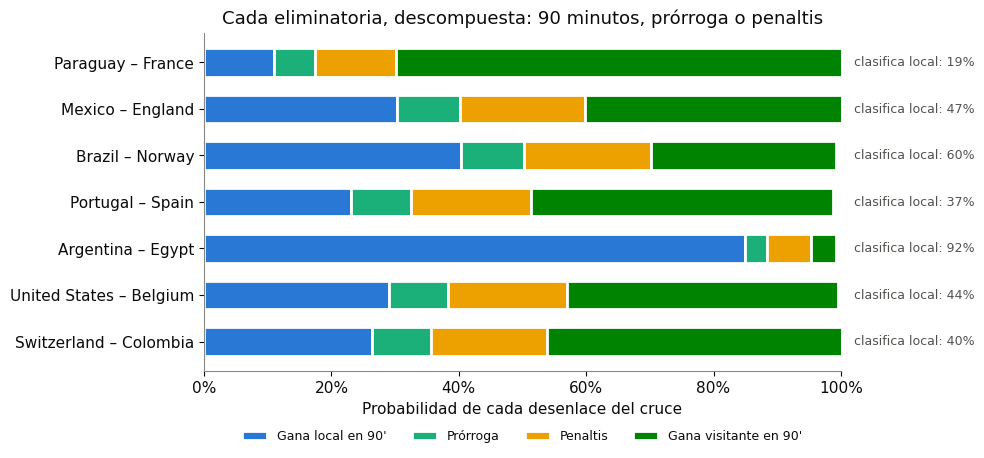

En estos 7 cruces, la probabilidad media de que el cruce pase de los 90' es 25% (prórroga 8%, penaltis 16%).


In [28]:
df_ko = pd.read_csv(DIR_RESULTS / "predicciones_proximos_partidos.csv", parse_dates=["fecha"])
if df_ko.empty or "prob_clasifica_local" not in df_ko.columns:
    df_ko = pd.read_csv(DIR_RESULTS / "predicciones_eliminatoria.csv", parse_dates=["fecha"])
df_ko = df_ko.dropna(subset=["prob_clasifica_local"]).copy()

# Cuatro salidas excluyentes que suman 1: gana A en 90', prórroga, penaltis, gana B en 90'
df_ko["p_local_90"] = df_ko["prob_local"]
df_ko["p_visitante_90"] = df_ko["prob_visitante"]
df_ko = df_ko.sort_values("fecha").tail(16)  # los cruces más recientes/pendientes

etiquetas = df_ko["equipo_local"] + " – " + df_ko["equipo_visitante"]
segmentos = [
    ("Gana local en 90'", df_ko["p_local_90"], AZUL),
    ("Prórroga", df_ko["prob_decide_prorroga"], AQUA),
    ("Penaltis", df_ko["prob_decide_penaltis"], AMARILLO),
    ("Gana visitante en 90'", df_ko["p_visitante_90"], VERDE),
]

fig, ax = plt.subplots(figsize=(10, 0.45 * len(df_ko) + 1.6))
izquierda = np.zeros(len(df_ko))
for nombre, valores, color in segmentos:
    ax.barh(etiquetas, valores, left=izquierda, color=color, label=nombre,
            height=0.62, edgecolor="white", linewidth=2)
    izquierda += valores.to_numpy()

for y, p in enumerate(df_ko["prob_clasifica_local"]):
    ax.text(1.02, y, f"clasifica local: {p:.0%}", va="center", fontsize=9, color="#52514e")

ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("Probabilidad de cada desenlace del cruce")
ax.set_title("Cada eliminatoria, descompuesta: 90 minutos, prórroga o penaltis", fontsize=13, color=TINTA)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=4, frameon=False, fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"En estos {len(df_ko)} cruces, la probabilidad media de que el cruce pase de los 90' es "
      f"{(df_ko['prob_decide_prorroga'] + df_ko['prob_decide_penaltis']).mean():.0%} "
      f"(prórroga {df_ko['prob_decide_prorroga'].mean():.0%}, penaltis {df_ko['prob_decide_penaltis'].mean():.0%}).")

## 15. Probabilidades por selección (Montecarlo, con lo jugado hasta hoy)

3.000 simulaciones completas del cuadro, con el checkpoint más reciente y los resultados ya
jugados fijados como conocidos -- no se "recalcula" lo que ya pasó, solo se propaga la
incertidumbre de lo que queda por decidir. A diferencia de las secciones 10-14 (100% modelo,
sin resultados reales), aquí sí se incorpora todo lo jugado hasta hoy.

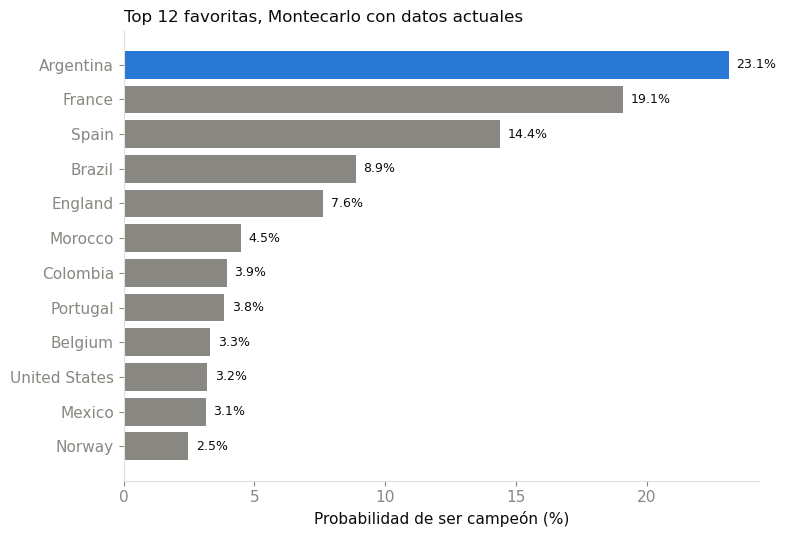

In [29]:
df_prob = pd.read_csv(DIR_RESULTS / "simulacion_probabilidades_actual.csv")
top_n = 12
top_equipos = df_prob.sort_values("campeon", ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(8, 5.5))
colores_ranking = [AZUL] + [GRIS] * (len(top_equipos) - 1)
ax.barh(top_equipos["seleccion"][::-1], top_equipos["campeon"][::-1] * 100, color=colores_ranking[::-1])
for i, v in enumerate(top_equipos["campeon"][::-1] * 100):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9, color=TINTA)
ax.set_xlabel("Probabilidad de ser campeón (%)")
ax.set_title(f"Top {top_n} favoritas, Montecarlo con datos actuales", loc="left", fontsize=12, color=TINTA)
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

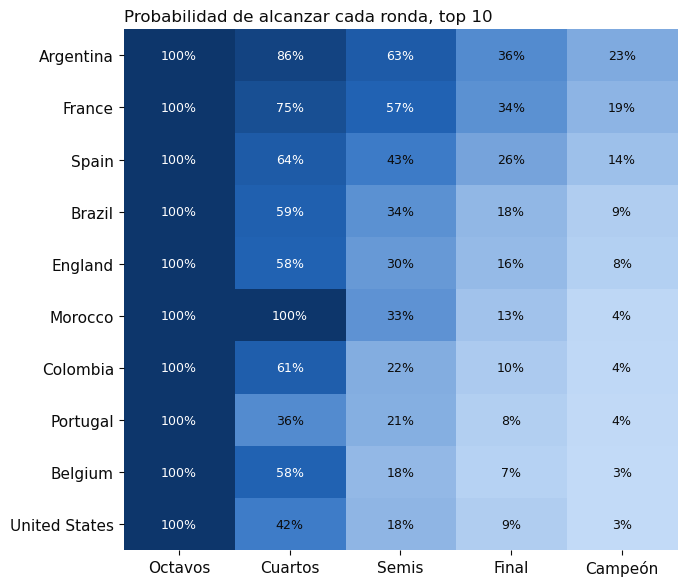

In [30]:
ETAPAS_MOSTRAR = ["alcanza_octavos", "alcanza_cuartos", "alcanza_semis", "alcanza_final", "campeon"]
ETIQUETAS_ETAPAS = ["Octavos", "Cuartos", "Semis", "Final", "Campeón"]

matriz = df_prob.sort_values("campeon", ascending=False).head(10).set_index("seleccion")[ETAPAS_MOSTRAR]

from matplotlib.colors import LinearSegmentedColormap
CMAP_SECUENCIAL = LinearSegmentedColormap.from_list("azul_secuencial", ["#cde2fb", "#256abf", "#0d366b"])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matriz.values, cmap=CMAP_SECUENCIAL, aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(ETIQUETAS_ETAPAS)))
ax.set_xticklabels(ETIQUETAS_ETAPAS)
ax.set_yticks(range(len(matriz.index)))
ax.set_yticklabels(matriz.index)
for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        valor = matriz.values[i, j]
        color_texto = "white" if valor > 0.55 else TINTA
        ax.text(j, i, f"{valor:.0%}", ha="center", va="center", fontsize=9, color=color_texto)
ax.set_title("Probabilidad de alcanzar cada ronda, top 10", loc="left", fontsize=12, color=TINTA)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

## 16. Contraste: el cuadro con lo ya jugado incorporado

Las secciones 10-14 ignoraron a propósito todo lo que ya ha pasado en 2026. Esta sección hace
lo contrario: cascada determinista real donde ya se jugó + predicho con el checkpoint más
reciente para el resto -- la vista que responde "¿qué pasaría desde HOY en adelante",
no "qué hubiera dicho el modelo el día 0". Los 32 cruces, de dieciseisavos a la final.
Página completa e interactiva en `results/bracket.html`.

In [31]:
df_cuadro = pd.read_csv(DIR_RESULTS / "cuadro_completo.csv")
campeon_previsto = df_cuadro.loc[df_cuadro["num_partido"] == 104, "ganador"].iloc[0]
finalistas = df_cuadro.loc[df_cuadro["num_partido"] == 104, ["equipo_a", "equipo_b"]].iloc[0]

print(f"Final prevista: {finalistas['equipo_a']} vs {finalistas['equipo_b']}")
print(f"Campeón previsto: {campeon_previsto}")
print(f"Visualización interactiva: {DIR_RESULTS / 'bracket.html'}\n")

df_cuadro_mostrar = df_cuadro[["ronda", "equipo_a", "equipo_b", "marcador", "ganador", "jugado"]].copy()
df_cuadro_mostrar["estado"] = df_cuadro_mostrar.pop("jugado").map({True: "JUGADO", False: "PREVISTO"})


def _resaltar_estado(fila):
    estilos = [""] * len(fila)
    idx = fila.index.get_loc("estado")
    estilos[idx] = f"color: {VERDE}; font-weight: bold" if fila["estado"] == "JUGADO" else f"color: {GRIS}"
    return estilos


df_cuadro_mostrar.style.apply(_resaltar_estado, axis=1).hide(axis="index")

Final prevista: Spain vs Argentina
Campeón previsto: Spain
Visualización interactiva: /Users/danielcanteragomez/portfolio/wc-2026-match-predictor/results/bracket.html



ronda,equipo_a,equipo_b,marcador,ganador,estado
Dieciseisavos de final,South Africa,Canada,0-1,Canada,JUGADO
Dieciseisavos de final,Germany,Paraguay,1-1,Paraguay,JUGADO
Dieciseisavos de final,Netherlands,Morocco,1-1,Morocco,JUGADO
Dieciseisavos de final,Brazil,Japan,2-1,Brazil,JUGADO
Dieciseisavos de final,France,Sweden,3-0,France,JUGADO
Dieciseisavos de final,Ivory Coast,Norway,1-2,Norway,JUGADO
Dieciseisavos de final,Mexico,Ecuador,2-0,Mexico,JUGADO
Dieciseisavos de final,England,DR Congo,2-1,England,JUGADO
Dieciseisavos de final,United States,Bosnia and Herzegovina,2-0,United States,JUGADO
Dieciseisavos de final,Belgium,Senegal,2-2,Belgium,JUGADO


## 16b. El modelo contra el mercado de apuestas: el benchmark definitivo

Las cuotas de cierre de una casa de apuestas son el pronóstico agregado más eficiente que
existe para un Mundial: integran alineaciones, lesiones, información privada y el dinero de
millones de apostantes. Comparamos el modelo contra las cuotas medias reales de mercado
(football-data.co.uk) en los 4 últimos Mundiales, con total disciplina anti-fuga (el modelo
de cada torneo se entrena solo con partidos anteriores).

**El resultado es el esperable y lo contamos tal cual: el mercado gana en los cuatro.** Una
simulación de apuestas con Kelly fraccionado sobre el "edge" aparente pierde ~80% de la
banca — el edge que el modelo cree ver es espejismo de calibración, y el propio módulo de
apuestas (`scripts/simulador_kelly.py`) lo detecta y lo avisa antes de apostar. Para un
proyecto de predicción esto no es un fracaso: es el techo de referencia que sitúa
honestamente todo lo demás.

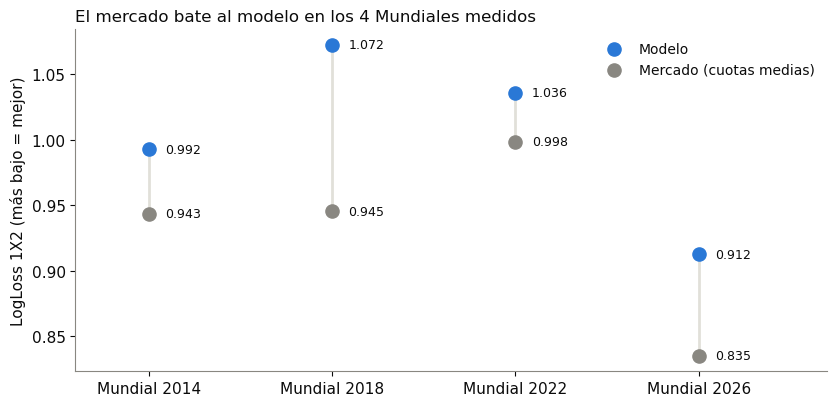

Diferencia media modelo-mercado: 0.0727 de LogLoss (peor torneo: +0.1268). No hay edge explotable contra cuotas de cierre.


In [32]:
df_bench = pd.read_csv(DIR_RESULTS / "apuestas_benchmark_mercado.csv")

# Dumbbell (puntos conectados), no barras: comparamos dos valores cuya diferencia
# vive lejos de cero -- una barra truncada exageraría, y una desde cero la ocultaría.
fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = np.arange(len(df_bench))
for xi, (m, k) in zip(x, zip(df_bench["logloss_modelo"], df_bench["logloss_mercado"])):
    ax.plot([xi, xi], [k, m], color=GRIS_CLARO, linewidth=2, zorder=1)
ax.scatter(x, df_bench["logloss_modelo"], s=90, color=AZUL, label="Modelo", zorder=2)
ax.scatter(x, df_bench["logloss_mercado"], s=90, color=GRIS, label="Mercado (cuotas medias)", zorder=2)
for xi, (m, k) in zip(x, zip(df_bench["logloss_modelo"], df_bench["logloss_mercado"])):
    ax.text(xi + 0.09, m, f"{m:.3f}", va="center", fontsize=9, color=TINTA)
    ax.text(xi + 0.09, k, f"{k:.3f}", va="center", fontsize=9, color=TINTA)

ax.set_xticks(x, [f"Mundial {a}" for a in df_bench["anio"]])
ax.set_xlim(-0.4, len(df_bench) - 0.3)
ax.set_ylabel("LogLoss 1X2 (más bajo = mejor)")
ax.set_title("El mercado bate al modelo en los 4 Mundiales medidos", loc="left", fontsize=12, color=TINTA)
ax.legend(frameon=False, fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()

peor_gap = (df_bench["logloss_modelo"] - df_bench["logloss_mercado"]).max()
print(f"Diferencia media modelo-mercado: {(df_bench['logloss_modelo'] - df_bench['logloss_mercado']).mean():.4f} "
      f"de LogLoss (peor torneo: +{peor_gap:.4f}). No hay edge explotable contra cuotas de cierre.")

## 17. Conclusiones y próximos pasos

**Lo que funciona bien**:
- Reentrenamiento walk-forward honesto: cada ronda se evalúa con el modelo tal como estaba
  ANTES de conocer su resultado, nunca al revés.
- La elección de familia de modelo (XGBoost) se apoya en evidencia de 5 Mundiales, no en un
  solo torneo -- un bootstrap sobre un único torneo daba un intervalo de confianza más ancho
  que la diferencia real entre familias.
- Tests que extraen y comprueban las funciones reales de los notebooks (no reimplementadas
  aparte), cubriendo justo los bugs matemáticos más sutiles que se encontraron por el camino.
- Las secciones 10-14 predicen el torneo entero (grupos, clasificados, mejores terceros,
  sorteo y cuadro completo) sin usar ningún resultado real de 2026 -- ni como feature ni para
  decidir quién avanza -- para que la sección 16 pueda contrastarlo limpiamente contra lo que
  de verdad ha pasado.

**Limitaciones conocidas, de más a menos impacto**:
1. **El techo está en los datos, no en el modelo**: Elo + forma + descanso + h2h no incluye
   bajas de jugadores, valor de plantilla, ni cuotas de casas de apuestas (el baseline
   estándar en toda la literatura de predicción de fútbol, y ausente aquí).
2. **Dixon-Coles es un parche de 1997** que solo corrige 4 celdas de la rejilla de
   marcadores -- un Poisson bivariante (Karlis & Ntzoufras) modelaría la correlación real
   entre ambos marcadores en toda la rejilla, no solo en los bajos.
3. El empate es el resultado estructuralmente más difícil (~23% de los casos): depende de
   que dos Poisson caigan exactamente igual, y ningún ajuste actual lo trata como una clase
   distinta a propósito.
4. La comparación de familias re-tunea hiperparámetros una sola vez por CV, sin repetir con
   distintas semillas -- no se ha medido cuánta varianza aporta la propia búsqueda de
   hiperparámetros.
5. **La clasificación de grupos (sección 11) usa un desempate simplificado** (Pts, DG, GF):
   no reproduce el criterio oficial de FIFA por enfrentamiento directo/fair play, que en
   algún grupo puntual podría cambiar quién pasa como 2º o como mejor tercero.
6. **El sorteo de dieciseisavos (sección 13) resuelve los huecos de "mejor tercero" con
   cualquier asignación válida**, no necesariamente la que usaría FIFA cuando hay más de una
   posible -- no cambia ningún marcador, solo qué asiento físico del cuadro ocupa cada
   tercero clasificado.
7. **Elo/forma/racha se congelan el día antes del Mundial** en las secciones 10-14 (no se
   actualizan ronda a ronda con marcadores previstos) -- mismo supuesto que ya usa la
   simulación Montecarlo del Notebook 4, documentado ahí por la misma razón: recalcularlos
   con resultados hipotéticos acumularía el propio error de predicción ronda tras ronda.

Este notebook es autocontenido: para reproducirlo fuera de este repositorio basta con subir
`data/processed/partidos_features.csv`, `data/raw/results.csv`,
`data/raw/wc2026_calendario.json`, la carpeta `results/` y
`models/checkpoints/pre_mundial/` como dataset adjunto, y ajustar `DIR_DATOS` en la primera
celda (las secciones 13-14 además necesitan acceso a internet para descargar la plantilla del
sorteo).

**Añadidos de la última iteración** (cada uno con su evidencia en `results/`):
- **Features de palmarés reciente** (títulos, finales, rendimiento vs. rivales top): primera
  incorporación de features que supera el estándar completo — mejor LogLoss en 48 de 82
  ediciones de torneos mayores desde 1990.
- **Ajuste de contexto de Mundial**: las fases finales son más cerradas que la mezcla de
  entrenamiento; corregirlo sube el marcador exacto de 10.1% a 12.1% en 5 Mundiales.
- **Módulo de prórroga/penaltis**: cada cruce se descompone en sus cuatro desenlaces reales
  en vez de fingir certeza — los penaltis son una moneda al aire y el modelo lo dice.
- **Benchmark contra el mercado**: las cuotas de cierre ganan en los 4 Mundiales medidos.
  Se publica igualmente porque un techo honesto vale más que un récord inflado.